# Peach: sistema de recomendación de películas

Este notebook desarrolla paso a paso el sistema de recomendación utilizado por Peach.

El proceso parte del conjunto de datos MovieLens 32M, construye una matriz dispersa de interacciones usuario–película y aplica una descomposición SVD truncada para representar usuarios y películas en un espacio latente de dimensión reducida.

A partir de las calificaciones iniciales de un usuario nuevo, el sistema estima su perfil latente mediante mínimos cuadrados regularizados y genera un ranking personalizado de películas.



## 1. Configuración e importaciones

En esta sección se cargan las librerías y se establecen los parámetros generales del sistema.

In [71]:
import os
import zipfile
import urllib.request

from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds

from IPython.display import display

import networkx as nx



In [72]:
# ============================================================
# ESTILO CIENTÍFICO GLOBAL PARA LAS FIGURAS DE PEACH
# ============================================================

from pathlib import Path

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import (
    AutoMinorLocator,
    LogLocator,
    NullFormatter,
    PercentFormatter
)

# ------------------------------------------------------------
# Paleta visual de PEACH
# ------------------------------------------------------------

PEACH_ORANGE = "#D9773D"
PEACH_ORANGE_DARK = "#A94F24"

PEACH_BLUE = "#3B6FB6"
PEACH_BLUE_DARK = "#264A78"

PEACH_YELLOW = "#D6A63A"
PEACH_GRAY = "#616A73"
PEACH_LIGHT_GRAY = "#D9DEE3"
PEACH_DARK = "#222222"

# Carpeta donde se guardarán las figuras.
FIGURES_DIR = Path("figuras_peach")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Configuración general de Matplotlib
# ------------------------------------------------------------

plt.rcParams.update({
    # Tipografía
    "font.family": "serif",
    "font.serif": [
        "DejaVu Serif",
        "Times New Roman",
        "STIXGeneral"
    ],
    "mathtext.fontset": "stix",
    "font.size": 14,

    # Títulos y etiquetas
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "axes.titleweight": "semibold",
    "axes.labelpad": 8,
    "axes.titlepad": 14,

    # Ejes
    "axes.linewidth": 0.8,
    "axes.edgecolor": PEACH_DARK,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.axisbelow": True,
    "axes.unicode_minus": True,

    # Ticks
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,

    # Líneas
    "lines.linewidth": 2.0,
    "lines.markersize": 6,

    # Cuadrícula
    "axes.grid": False,
    "grid.color": "gray",
    "grid.linewidth": 0.4,
    "grid.alpha": 0.30,
    "grid.linestyle": "--",

    # Leyendas
    "legend.frameon": False,
    "legend.fontsize": 11,

    # Figuras y exportación
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
    "savefig.pad_inches": 0.05
})


def apply_scientific_axis_style(
    ax,
    grid_axis="both",
    minor_grid=False
):
    """
    Aplica una cuadrícula discreta y configura los ticks
    sin modificar los datos representados.
    """

    ax.grid(
        True,
        which="major",
        axis=grid_axis,
        linestyle="--",
        linewidth=0.4,
        alpha=0.30
    )

    if minor_grid:
        ax.grid(
            True,
            which="minor",
            axis=grid_axis,
            linestyle=":",
            linewidth=0.3,
            alpha=0.16
        )

    ax.tick_params(
        which="major",
        direction="in",
        length=6
    )

    ax.tick_params(
        which="minor",
        direction="in",
        length=3
    )


def save_scientific_figure(
    fig,
    filename,
    save_pdf=True
):
    """
    Guarda una versión PNG de alta resolución y, opcionalmente,
    una versión PDF vectorial.
    """

    png_path = FIGURES_DIR / f"{filename}.png"

    fig.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight"
    )

    if save_pdf:
        pdf_path = FIGURES_DIR / f"{filename}.pdf"

        fig.savefig(
            pdf_path,
            bbox_inches="tight"
        )

In [73]:
# ============================================================
# CONFIGURACIÓN GENERAL DE PEACH
# ============================================================

# Dimensión del espacio latente
K = 50

# Regularización usada para estimar el perfil del usuario nuevo
LAMBDA_REG = 0.1

# Ranking completo y tamaño de cada bloque visible
N_RECOMMENDATIONS = 30
ROLL_SIZE = 10
MAX_ROUNDS = 3

# Requisito actual de Peach para habilitar el mapa
MIN_RATINGS_FOR_MAP = 5

# Parámetros que usará posteriormente el mapa de afinidades
N_NEIGHBORS = 5
MIN_NEIGHBOR_RATINGS = 5
POSITIVE_THRESHOLD = 4.0
AFFINITY_METRIC = "cosine"

# Cantidad de descubrimientos sociales
N_SOCIAL_DISCOVERIES = 10

# Peso de cada componente del ranking social
SOCIAL_COMPONENT_WEIGHT = 0.70
SVD_COMPONENT_WEIGHT = 0.30

# Parámetros del onboarding
TOP_N_PER_GENRE = 20
ONBOARDING_POOL_SIZE = 200

# Reproducibilidad
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

## 2. Descarga y lectura de MovieLens 32M

Se descarga el conjunto de datos MovieLens 32M y se leen sus tres archivos principales:

- `movies.csv`: información de las películas.
- `ratings.csv`: calificaciones realizadas por los usuarios.
- `tags.csv`: etiquetas descriptivas asociadas a las películas.

In [74]:
# =========================
# 2. Carga del dataset
# =========================
url = "https://files.grouplens.org/datasets/movielens/ml-32m.zip"

zip_path = "/content/ml-32m.zip"
extract_path = "/content"
path = "/content/ml-32m"

urllib.request.urlretrieve(url, zip_path)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

os.listdir(path)

['checksums.txt',
 'tags.csv',
 'ratings.csv',
 'movies.csv',
 'links.csv',
 'README.txt']

In [75]:
# =========================
# 3. Lectura de archivos CSV
# =========================
movies = pd.read_csv(f"{path}/movies.csv")
ratings = pd.read_csv(f"{path}/ratings.csv")
tags = pd.read_csv(f"{path}/tags.csv")

In [76]:
# =========================
# 4. Vista inicial de los datos
# =========================
print(movies.head()) #head() muestra las primeras 5 filas por deffault = head(5)
print(ratings.head())
print(tags.head())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
   userId  movieId  rating  timestamp
0       1       17     4.0  944249077
1       1       25     1.0  944250228
2       1       29     2.0  943230976
3       1       30     5.0  944249077
4       1       32     5.0  943228858
   userId  movieId          tag   timestamp
0      22    26479  Kevin Kline  1583038886
1      22    79592     misogyny  1581476297
2      22   247150   acrophobia  1622483469
3

## 3. Limpieza y validación de los datos

Se eliminan duplicados, valores faltantes y registros que no cumplen con la estructura esperada. Después de la limpieza se conservan únicamente las columnas necesarias para entrenar y explicar el sistema.

In [77]:
# =========================
# 5. Exploración inicial
# =========================

print("movies:", movies.shape)
print("ratings:", ratings.shape)
print("tags:", tags.shape)

movies: (87585, 3)
ratings: (32000204, 4)
tags: (2000072, 4)


In [78]:
print(movies.columns)
print(ratings.columns)
print(tags.columns)

Index(['movieId', 'title', 'genres'], dtype='object')
Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')
Index(['userId', 'movieId', 'tag', 'timestamp'], dtype='object')


In [79]:
# =========================
# 6. Resumen de valores faltantes
# =========================
def missing_summary(df):
    return pd.DataFrame({
        "columna": df.columns,
        "n_missing": df.isna().sum().values
    })

In [80]:
print(missing_summary(movies) )
print()
print(missing_summary(ratings))
print()
print(missing_summary(tags))

   columna  n_missing
0  movieId          0
1    title          0
2   genres          0

     columna  n_missing
0     userId          0
1    movieId          0
2     rating          0
3  timestamp          0

     columna  n_missing
0     userId          0
1    movieId          0
2        tag         17
3  timestamp          0


In [81]:
# =========================
# 7. Eliminación de duplicados
# =========================

movies = movies.drop_duplicates()
ratings = ratings.drop_duplicates()
tags = tags.drop_duplicates()

In [82]:
# =========================
# 8. Limpieza de ratings
# =========================

ratings_clean = ratings.dropna()

ratings_clean = ratings_clean[
    (ratings_clean["rating"] >= 0.5) &
    (ratings_clean["rating"] <= 5.0)
]

ratings_clean = ratings_clean[["userId", "movieId", "rating"]]

In [83]:
# =========================
# 9. Limpieza de movies
# =========================

movies_clean = movies.dropna()
movies_clean = movies_clean.drop_duplicates()

movies_clean = movies_clean[["movieId", "title", "genres"]]

In [84]:
# =========================
# 10. Limpieza de tags
# =========================

tags_clean = tags.dropna()
tags_clean = tags_clean.drop_duplicates()

tags_clean = tags_clean[["userId", "movieId", "tag"]]

In [85]:
print("Filas originales:", len(tags))
print("Filas después de limpieza:", len(tags_clean))
print("Filas eliminadas:", len(tags) - len(tags_clean))

Filas originales: 2000072
Filas después de limpieza: 2000055
Filas eliminadas: 17


In [86]:
# =========================
# 11. Dimensiones finales
# =========================

print("movies_clean:", movies_clean.shape)
print("ratings_clean:", ratings_clean.shape)
print("tags_clean:", tags_clean.shape)

movies_clean: (87585, 3)
ratings_clean: (32000204, 3)
tags_clean: (2000055, 3)


## 4. Análisis exploratorio


### 4.1 Análisis de tags

Se calcula la frecuencia de aparición de cada tag para identificar cuáles son más utilizados y qué tan disperso es el vocabulario descriptivo de MovieLens.

Las cifras se calculan directamente en las celdas siguientes para evitar que la documentación quede desactualizada respecto a los datos cargados.

In [87]:
# =========================
# 13. Análisis de los tags
# =========================

print("Tags únicos:", tags_clean["tag"].nunique())

Tags únicos: 140979


In [88]:
# Frecuencia de cada tag
tag_freq = (
    tags_clean
    .groupby("tag")
    .size()
    .reset_index(name="count")
)

In [89]:
# Ordenar de mayor a menor frecuencia
tag_freq = tag_freq.sort_values(by="count", ascending=False)

print(tag_freq.head(50))

                          tag  count
114520                 sci-fi  10996
32719             atmospheric   9589
28218                  action   8473
47165                  comedy   8139
65290                   funny   7467
125650                surreal   7231
135355     visually appealing   7090
34912         based on a book   6617
132319           twist ending   6521
50948             dark comedy   6053
128847      thought-provoking   6000
56018                dystopia   5646
135120               violence   5389
45521          cinematography   5277
112370                romance   5271
89906                  murder   5180
120662      social commentary   5152
124779               stylized   4917
60423                 fantasy   4844
101866             psychology   4827
129534            time travel   4682
102707                 quirky   4650
50936                    dark   4529
45812                 classic   4482
28650               adventure   4387
47288           coming of age   4350
6

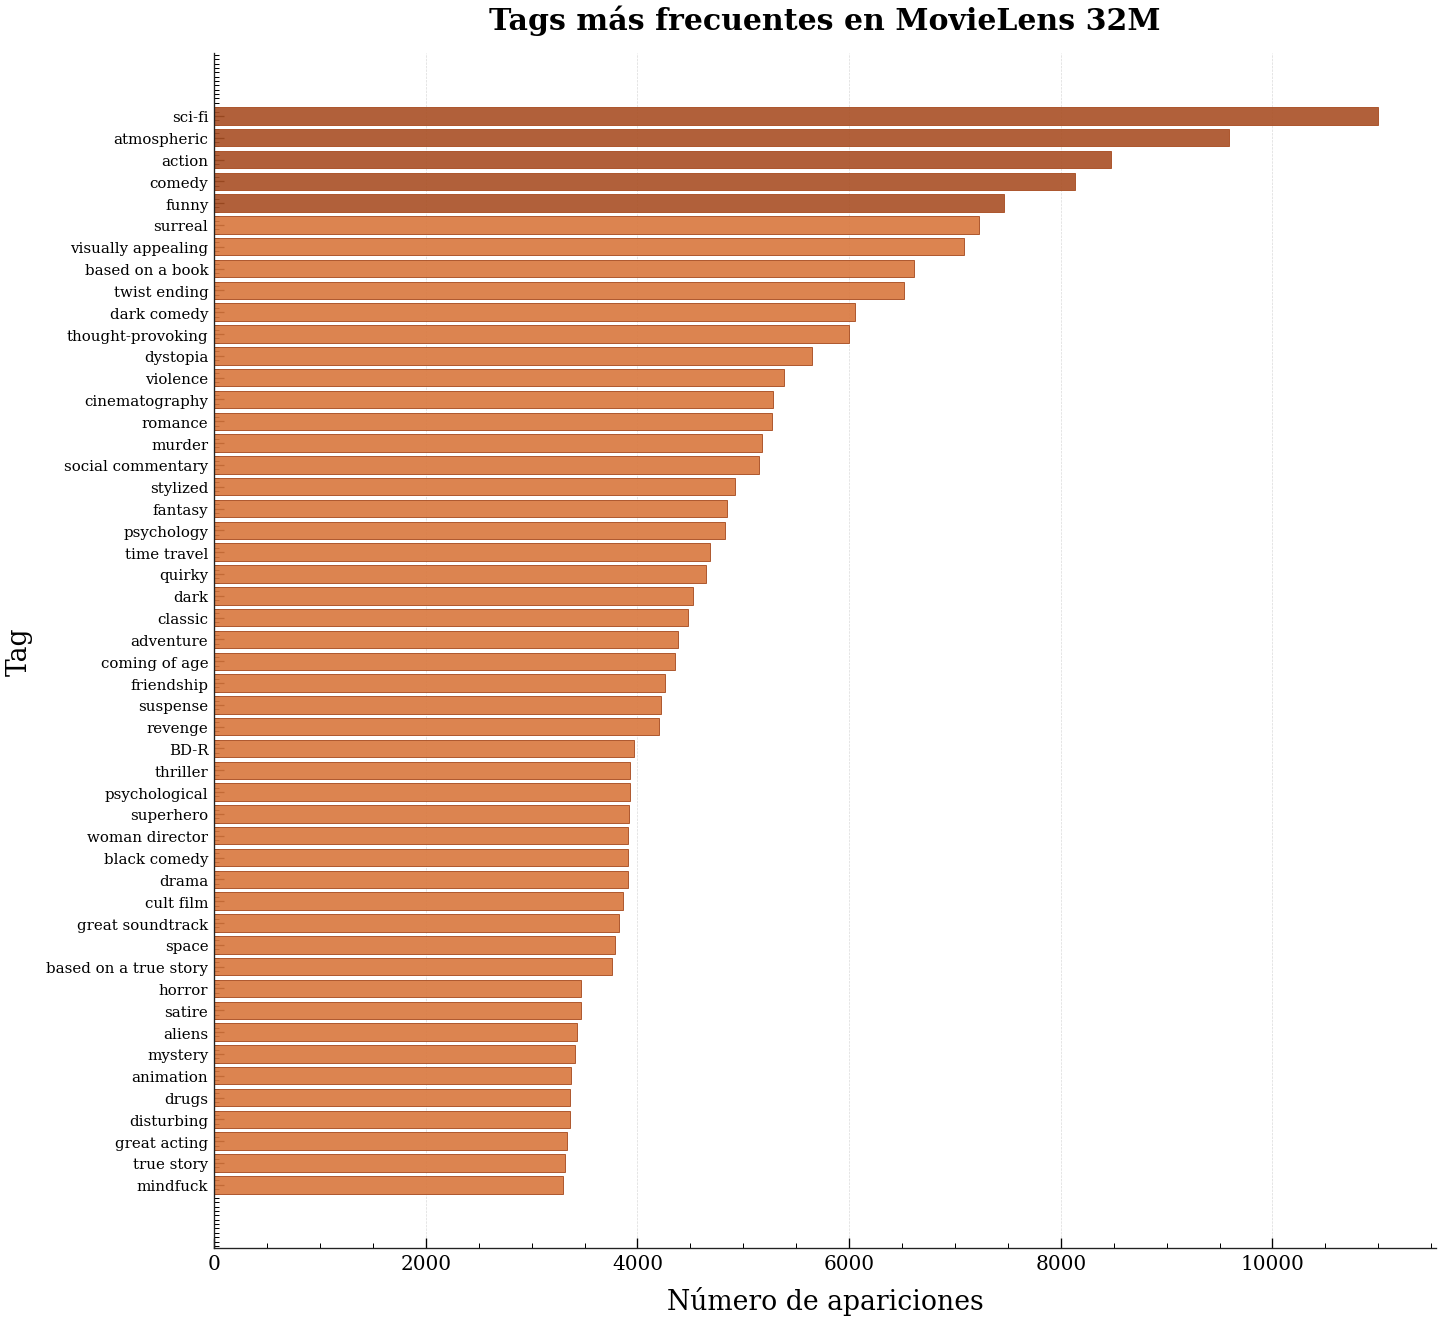

In [90]:
# ============================================================
# TOP 50 TAGS MÁS FRECUENTES
# ============================================================

top50 = (
    tag_freq
    .head(50)
    .iloc[::-1]
    .copy()
)

fig, ax = plt.subplots(
    figsize=(12, 11),
    layout="constrained"
)

bars = ax.barh(
    top50["tag"],
    top50["count"],
    color=PEACH_ORANGE,
    edgecolor=PEACH_ORANGE_DARK,
    linewidth=0.6,
    alpha=0.90
)

ax.set_title(
    "Tags más frecuentes en MovieLens 32M"
)

ax.set_xlabel(
    "Número de apariciones"
)

ax.set_ylabel(
    "Tag"
)

# Mantener una escala lineal porque se trata de barras
# que representan frecuencias absolutas.
ax.set_xlim(
    left=0
)

# Cuadrícula únicamente sobre el eje cuantitativo.
apply_scientific_axis_style(
    ax,
    grid_axis="x"
)

# Los 50 nombres requieren un tamaño ligeramente menor.
ax.tick_params(
    axis="y",
    labelsize=9
)

# Resaltar los cinco tags con mayor frecuencia.
for bar in bars[-5:]:
    bar.set_facecolor(PEACH_ORANGE_DARK)

save_scientific_figure(
    fig,
    "top50_tags"
)

plt.show()

In [91]:
# Estadísticas de frecuencia
print("Mínimo:", tag_freq["count"].min())
print("Máximo:", tag_freq["count"].max())
print("Media:", tag_freq["count"].mean())
print("Mediana:", tag_freq["count"].median())

Mínimo: 1
Máximo: 10996
Media: 14.18690017662205
Mediana: 1.0


In [92]:
# Tags que aparecen solo una vez
tags_una_vez = (tag_freq["count"] == 1).sum()

print("Tags con frecuencia 1:", tags_una_vez)

Tags con frecuencia 1: 73175


In [93]:
# Porcentaje de tags que aparecen solo una vez
porcentaje_tags_una_vez = 100 * tags_una_vez / len(tag_freq)

print("Porcentaje:", porcentaje_tags_una_vez)

Porcentaje: 51.90489363664092


### 4.2 Análisis de ratings y actividad de usuarios

Se estudia la distribución de las calificaciones y la cantidad de interacciones realizadas por cada usuario.

Este análisis permite verificar que los usuarios presentes en MovieLens poseen suficiente información para aprender representaciones latentes útiles.

In [94]:
# =========================
# 14. Análisis de ratings
# =========================

# Usuarios únicos
print("Usuarios únicos:", ratings_clean["userId"].nunique())

# Películas únicas
print("Películas únicas:", ratings_clean["movieId"].nunique())

Usuarios únicos: 200948
Películas únicas: 84432


In [95]:
#distribucion de lOS ratings
rating_distribution = (
    ratings_clean
    .groupby("rating")
    .size()
    .reset_index(name="count")
    .sort_values("rating")
)

print(rating_distribution)

   rating    count
0     0.5   525132
1     1.0   946675
2     1.5   531063
3     2.0  2028622
4     2.5  1685386
5     3.0  6054990
6     3.5  4290105
7     4.0  8367654
8     4.5  2974000
9     5.0  4596577


In [96]:
#Verficacion de usuarios activos

user_counts = (
    ratings_clean
    .groupby("userId")
    .size()
    .reset_index(name="n_ratings")
)

In [97]:
print(user_counts[["n_ratings"]].describe())

           n_ratings
count  200948.000000
mean      159.246193
std       282.025462
min        20.000000
25%        36.000000
50%        73.000000
75%       167.000000
max     33332.000000


In [98]:
print("Mínimo:", user_counts["n_ratings"].min())
print("Máximo:", user_counts["n_ratings"].max())
print("Media:", user_counts["n_ratings"].mean())
print("Mediana:", user_counts["n_ratings"].median())

Mínimo: 20
Máximo: 33332
Media: 159.24619304496684
Mediana: 73.0


## 5. Construcción de la matriz usuario–película

Cada fila de la matriz representa un usuario y cada columna representa una película.

La mayoría de las combinaciones usuario–película no contiene una calificación observada. Por esta razón, la matriz se almacena en formato disperso `CSR`, evitando reservar memoria para las entradas vacías.

La densidad y el porcentaje de dispersión se calculan directamente en las siguientes celdas.

In [99]:
# =========================
# 15. Construcción de matriz usuario-película
# =========================

# Número de usuarios únicos
n_users = ratings_clean["userId"].nunique()

# Número de películas únicas
n_movies = ratings_clean["movieId"].nunique()

print("Usuarios:", n_users)
print("Películas:", n_movies)

Usuarios: 200948
Películas: 84432


In [100]:
# =========================
# 16. Cálculo de densidad de la matriz
# =========================

# Ratings posibles si todos los usuarios calificaran todas las películas
possible = n_users * n_movies

# Ratings realmente observados
actual = len(ratings_clean)

# Densidad de la matriz
density = actual / possible

print("Ratings observados:", actual)
print("Ratings posibles:", possible)
print("Densidad:", density)
print("Densidad (%):", density * 100)

Ratings observados: 32000204
Ratings posibles: 16966441536
Densidad: 0.0018860881306254364
Densidad (%): 0.18860881306254365


In [101]:
# ============================================================
# CONSTRUCCIÓN DE ÍNDICES Y MATRIZ DISPERSA
# ============================================================

# IDs reales ordenados para obtener una correspondencia determinista
user_ids = np.sort(ratings_clean["userId"].unique())
movie_ids = np.sort(ratings_clean["movieId"].unique())

# ID real -> posición interna
user_map = {
    int(user_id): idx
    for idx, user_id in enumerate(user_ids)
}

movie_map = {
    int(movie_id): idx
    for idx, movie_id in enumerate(movie_ids)
}

# Convertir cada interacción en una posición fila-columna
rows = ratings_clean["userId"].map(user_map).to_numpy()
cols = ratings_clean["movieId"].map(movie_map).to_numpy()
vals = ratings_clean["rating"].astype(float).to_numpy()

R = csr_matrix(
    (vals, (rows, cols)),
    shape=(len(user_ids), len(movie_ids))
)

print("Matriz R creada")
print("Forma:", R.shape)
print("Ratings observados:", R.nnz)
print("Densidad:", R.nnz / (R.shape[0] * R.shape[1]))

Matriz R creada
Forma: (200948, 84432)
Ratings observados: 32000204
Densidad: 0.0018860881306254364


In [102]:
# ============================================================
# SVD TRUNCADA
# ============================================================

U, S, Vt = svds(R, k=K)

# svds devuelve los valores singulares en orden ascendente
order = np.argsort(S)[::-1]

S = S[order]
U = U[:, order]
Vt = Vt[order, :]

print("U:", U.shape)
print("S:", S.shape)
print("Vt:", Vt.shape)

print("\nPrimeros valores singulares:")
print(S[:10])

U: (200948, 50)
S: (50,)
Vt: (50, 84432)

Primeros valores singulares:
[9032.38102201 4265.13020478 2962.83432586 2856.37494764 2441.34461236
 2269.55931732 2169.8992637  1848.47223494 1701.69413469 1528.15832014]


## 6. Complejidad computacional

La matriz usuario–película es altamente dispersa. Almacenar todas sus entradas en formato denso requeriría reservar memoria incluso para las combinaciones que no poseen una calificación.

El formato disperso almacena únicamente los ratings observados. La SVD truncada aprovecha esta representación y conserva solamente los primeros K factores latentes.

Como referencia sencilla del crecimiento computacional, se utiliza el valor:

$$
\operatorname{nnz}(R)\cdot K
$$

donde $\operatorname{nnz}(R)$ representa la cantidad de entradas no nulas de la matriz.


In [103]:
n_users, n_movies = R.shape
total_entries = n_users * n_movies

print("Usuarios:", n_users)
print("Películas:", n_movies)
print("Entradas posibles:", total_entries)

Usuarios: 200948
Películas: 84432
Entradas posibles: 16966441536


In [104]:
bytes_dense = total_entries * 8

gib_dense = bytes_dense / (1024**3)
gb_dense = bytes_dense / 1e9

print(f"Memoria aproximada en formato denso: {gib_dense:.2f} GiB")
print(f"Equivalente decimal: {gb_dense:.2f} GB")

Memoria aproximada en formato denso: 126.41 GiB
Equivalente decimal: 135.73 GB


In [105]:
nnz = R.nnz #Number of non zero elements
density = nnz / total_entries

print("Ratings observados:", nnz)
print(f"Densidad: {density:.6f}")
print(f"Densidad porcentual: {density*100:.4f}%")

Ratings observados: 32000204
Densidad: 0.001886
Densidad porcentual: 0.1886%


In [106]:
k_values = [10, 20, 50, 100, 200, 300, 400, 500]

cost_proxy = [nnz * k for k in k_values]

for k_val, c in zip(k_values, cost_proxy):
    print(f"k={k_val:3d} -> nnz*k = {c:,}")

k= 10 -> nnz*k = 320,002,040
k= 20 -> nnz*k = 640,004,080
k= 50 -> nnz*k = 1,600,010,200
k=100 -> nnz*k = 3,200,020,400
k=200 -> nnz*k = 6,400,040,800
k=300 -> nnz*k = 9,600,061,200
k=400 -> nnz*k = 12,800,081,600
k=500 -> nnz*k = 16,000,102,000


## 7. Construcción de los espacios latentes de usuarios y películas

La SVD truncada produce la aproximación:

$$
R \approx U\Sigma V^\top
$$

Para Peach se construye la matriz:

$$
Q=(\Sigma V^\top)^\top
$$

de manera que:

$$
R\approx UQ^\top
$$

Con esta parametrización:

- Cada fila de $U$ representa el perfil latente de un usuario existente.
- Cada fila de $Q$ representa el perfil latente de una película.
- El perfil de un usuario nuevo puede estimarse en el mismo espacio de las filas de $U$.
- Las recomendaciones se calculan mediante $Qp_u$.

Conservar simultáneamente $U$ y $Q$ permitirá generar las recomendaciones individuales y, posteriormente, buscar usuarios con preferencias latentes similares.

In [107]:
# ============================================================
# MAPAS ENTRE IDS REALES E ÍNDICES INTERNOS
# ============================================================

movie_id_to_col = movie_map
col_to_movie_id = {
    col: int(movie_id)
    for movie_id, col in movie_map.items()
}

user_id_to_row = user_map
row_to_user_id = {
    row: int(user_id)
    for user_id, row in user_map.items()
}

print("Películas en el mapa:", len(movie_id_to_col))
print("Usuarios en el mapa:", len(user_id_to_row))

Películas en el mapa: 84432
Usuarios en el mapa: 200948


In [108]:
# ============================================================
# MATRIZ LATENTE DE PELÍCULAS
# ============================================================

Q = (np.diag(S) @ Vt).T

print("Forma de U:", U.shape)
print("Forma de Q:", Q.shape)
print("Dimensión latente K:", K)

Forma de U: (200948, 50)
Forma de Q: (84432, 50)
Dimensión latente K: 50


## 8. Construcción del usuario nuevo
Para manejar el problema de *cold start*, el sistema permite crear un perfil inicial del usuario mediante tres rutas:

1. **Películas vistas:** el usuario selecciona películas que conoce y las califica. Estas calificaciones se usan después para estimar su perfil latente con SVD.
2. **Géneros favoritos:** el usuario elige géneros de interés y el sistema recomienda películas populares y bien valoradas dentro de esos géneros.
3. **Recomendación global:** si el usuario no entrega preferencias, el sistema recomienda películas populares con buena calificación promedio.

En la primera ruta, las películas mostradas no aparecen siempre en el mismo orden. Se toma un conjunto de películas populares y se mezcla aleatoriamente antes de presentarlo por bloques, para hacer la interacción menos repetitiva.

La información inicial se guarda en `new_user`, con los campos:

* `name`: nombre del usuario.
* `mode`: ruta de recomendación elegida.
* `ratings`: películas calificadas por el usuario.
* `genres`: géneros favoritos seleccionados.

Además, el sistema muestra recomendaciones por rondas. Si al usuario no le gustan las primeras opciones, puede pedir otro bloque dentro del ranking generado.



In [109]:
# Estadísticas de popularidad y valoración por película
movie_stats = (
    ratings_clean
    .groupby("movieId")
    .agg(
        n_ratings=("rating", "count"),
        avg_rating=("rating", "mean")
    )
    .reset_index()
)

print(movie_stats.head())

   movieId  n_ratings  avg_rating
0        1      68997    3.897438
1        2      28904    3.275758
2        3      13134    3.139447
3        4       2806    2.845331
4        5      13154    3.059602


In [110]:
#prep pelis populares por generos
def build_genre_movies(movies_clean, movie_stats, top_n=20):
    genres = set()

    for g in movies_clean["genres"]:
        genres.update(g.split("|"))

    genres.discard("(no genres listed)")
    genres.discard("IMAX")
    genres = sorted(genres)

    genre_movies = {}

    for genre in genres:
        top_movies = (
            movies_clean[
                movies_clean["genres"].str.contains(genre, na=False, regex=False)
            ]
            .merge(movie_stats, on="movieId")
            .sort_values("n_ratings", ascending=False)
            [["movieId", "title", "genres", "n_ratings", "avg_rating"]]
            .head(top_n)
        )

        genre_movies[genre] = top_movies

    return genres, genre_movies

In [111]:
#mostrar pelis en bloques
def ask_seen_movies(candidate_movies,block_size=ROLL_SIZE,min_movies=MIN_RATINGS_FOR_MAP):
    candidate_movies = candidate_movies.reset_index(drop=True).copy()
    candidate_movies["option_id"] = candidate_movies.index + 1

    movie_queue = deque(candidate_movies.to_dict("records"))
    selected_ids = set()

    print("\nTe mostraremos películas populares.")
    print("Selecciona las películas que hayas visto.")
    print(
        f"Necesitamos al menos {min_movies} películas "
        "para construir tu perfil y habilitar el mapa."
        )
    print("Escribe los números separados por comas.")
    print("Si no viste ninguna en un bloque, presiona Enter.\n")

    while movie_queue:
        block = []

        for _ in range(min(block_size, len(movie_queue))):
            block.append(movie_queue.popleft())

        print("\nPelículas:")

        for movie in block:
            print(f"{movie['option_id']}. {movie['title']}")

        choice = input("\n¿Cuáles has visto? ").strip()

        if choice != "":
            for x in choice.split(","):
                x = x.strip()

                if x.isdigit():
                    option_id = int(x)

                    valid_ids = [m["option_id"] for m in block]

                    if option_id in valid_ids:
                        selected_ids.add(option_id)
                    else:
                        print(f"El número {option_id} no está en este bloque.")

        selected_movies = candidate_movies[
            candidate_movies["option_id"].isin(selected_ids)
        ].copy()

        print("\nPelículas seleccionadas hasta ahora:")

        if selected_movies.empty:
            print("Ninguna")
        else:
            for _, row in selected_movies.iterrows():
                print(f"{row['option_id']}. {row['title']}")

        if len(selected_movies) >= min_movies:
            while True:
                stop = input("\n¿Quieres seguir viendo más películas? (s/n): ").lower().strip()

                if stop == "s":
                    break

                elif stop == "n":
                    return selected_movies.drop(columns=["option_id"]).reset_index(drop=True)

                else:
                    print("Escribe solo 's' o 'n'.")

    selected_movies = candidate_movies[
        candidate_movies["option_id"].isin(selected_ids)
    ].copy()

    return selected_movies.drop(columns=["option_id"]).reset_index(drop=True)

In [112]:
#pedir ratings
def ask_ratings_for_movies(seen_movies):
    user_ratings = {}

    if seen_movies.empty:
        return user_ratings

    print("\nAhora califica las películas que seleccionaste.")
    print("Usa valores entre 0.5 y 5.0\n")

    for _, row in seen_movies.iterrows():
        while True:
            rating = input(f"{row['title']}: ").strip()

            try:
                rating = float(rating)

                if 0.5 <= rating <= 5.0:
                    user_ratings[row["movieId"]] = rating
                    break
                else:
                    print("El rating debe estar entre 0.5 y 5.0")

            except:
                print("Ingresa un número válido.")

    return user_ratings

In [113]:
#pedir generos favoritos
def ask_favorite_genres(genres, max_genres=8):
    print("\nGéneros disponibles:\n")

    for i, genre in enumerate(genres, start=1):
        print(f"{i}. {genre}")

    print(f"\nElige entre 1 y {max_genres} géneros.")
    print("Escribe los números separados por comas.")
    print("Ejemplo: 1,5,8,15")
    print("Si no tienes preferencia, presiona Enter.")

    choice = input("\nGéneros favoritos: ").strip()

    if choice == "":
        return []

    selected_genres = []

    for x in choice.split(","):
        x = x.strip()

        if x.isdigit():
            idx = int(x)

            if 1 <= idx <= len(genres):
                selected_genres.append(genres[idx - 1])

    selected_genres = list(dict.fromkeys(selected_genres))

    if len(selected_genres) > max_genres:
        print(f"\nElegiste más de {max_genres}. Se tomarán solo los primeros {max_genres}.")

    return selected_genres[:max_genres]

In [114]:
#recomm por generos
def recommend_by_genres(selected_genres, genre_movies, n_recommendations=10):
    if len(selected_genres) == 0:
        return pd.DataFrame()

    recs = pd.concat([genre_movies[g] for g in selected_genres])

    recs = (
        recs
        .drop_duplicates(subset="movieId")
        .sort_values(["avg_rating", "n_ratings"], ascending=False)
        .head(n_recommendations)
    )

    return recs

In [115]:
#recomm global
def recommend_global(movie_stats, movies_clean, n_recommendations=10):
    popular = movie_stats[movie_stats["n_ratings"] >= 1000].copy()

    popular["score"] = (
        popular["n_ratings"].rank(pct=True) * 0.7
        + popular["avg_rating"].rank(pct=True) * 0.3
    )

    recs = (
        popular
        .merge(movies_clean, on="movieId")
        .sort_values("score", ascending=False)
        .head(n_recommendations)
    )

    return recs[["movieId", "title", "genres", "n_ratings", "avg_rating", "score"]]

In [116]:
# =========================
# Elegir modo de recomendación
# =========================

def choose_recommendation_mode():
    print("\n===== Sistema de recomendación =====")
    print("Elige una opción:")
    print("1. Recomendar según películas que he visto")
    print("2. Recomendar según géneros favoritos")
    print("3. Recomendar películas populares/globales")

    while True:
        choice = input("\nOpción: ").strip()

        if choice in ["1", "2", "3"]:
            return choice

        print("Elige una opción válida: 1, 2 o 3.")


# =========================
# Nuevo usuario
# =========================

def new_user_console_flow(
    movies_clean,
    movie_stats,
    block_size=ROLL_SIZE,
    top_n_per_genre=TOP_N_PER_GENRE,
    n_recommendations=N_RECOMMENDATIONS,
    onboarding_pool_size=ONBOARDING_POOL_SIZE,
    random_state=None
):
    print("===== Crear nuevo usuario =====")

    user_name = input("Ingresa tu nombre: ").strip()

    genres, genre_movies = build_genre_movies(
        movies_clean=movies_clean,
        movie_stats=movie_stats,
        top_n=top_n_per_genre
    )

    mode = choose_recommendation_mode()

    initial_recommendations = pd.DataFrame()

    # Caso 1: usuario conoce películas
    if mode == "1":
        candidate_movies = pd.concat(genre_movies.values())

        candidate_movies = (
            candidate_movies
            .drop_duplicates(subset="movieId")
            .sort_values("n_ratings", ascending=False)
            .head(onboarding_pool_size)
            .sample(frac=1, random_state=random_state)
            .reset_index(drop=True)
        )

        seen_movies = ask_seen_movies(
            candidate_movies=candidate_movies,
            block_size=block_size,
            min_movies=MIN_RATINGS_FOR_MAP
        )
        if len(seen_movies) < MIN_RATINGS_FOR_MAP:
          raise ValueError(
              f"Se requieren al menos {MIN_RATINGS_FOR_MAP} películas "
              "para continuar con la ruta SVD."
          )

        print("\nPelículas finales seleccionadas:")

        if seen_movies.empty:
            print("No se seleccionaron películas.")
        else:
            print(seen_movies[["movieId", "title"]])

        user_ratings = ask_ratings_for_movies(seen_movies)

        selected_genres = ask_favorite_genres(genres, max_genres=5)

        new_user = {
            "name": user_name,
            "mode": "svd",
            "ratings": user_ratings,
            "genres": selected_genres
        }

    # Caso 2: usuario elige géneros
    elif mode == "2":
        selected_genres = ask_favorite_genres(genres, max_genres=5)

        new_user = {
            "name": user_name,
            "mode": "genres",
            "ratings": {},
            "genres": selected_genres
        }

        initial_recommendations = recommend_by_genres(
            selected_genres=selected_genres,
            genre_movies=genre_movies,
            n_recommendations=n_recommendations
        )

    # Caso 3: usuario no da preferencias
    else:
        new_user = {
            "name": user_name,
            "mode": "global",
            "ratings": {},
            "genres": []
        }

        initial_recommendations = recommend_global(
            movie_stats=movie_stats,
            movies_clean=movies_clean,
            n_recommendations=n_recommendations
        )

    return new_user, initial_recommendations

In [117]:
# =========================
# Mostrar recomendaciones
# =========================

def display_recommendations(recommendations, title="Recomendaciones"):
    """
    Muestra recomendaciones de forma legible.
    Se usa en las rondas interactivas antes del resultado final.
    """

    print("\n" + "=" * 60)
    print(f"🎞️ {title}")
    print("=" * 60)

    if recommendations is None or recommendations.empty:
        print("No hay recomendaciones disponibles.")
        return

    recommendations = recommendations.reset_index(drop=True)

    movie_emojis = ["🎬", "🍿", "🎞️", "📽️", "🎥", "⭐", "🏆", "🎭", "🔥", "✨"]

    for i, row in recommendations.iterrows():
        emoji = movie_emojis[i % len(movie_emojis)]

        print(f"\n{emoji} {i + 1}. {row['title']}")

        if "genres" in recommendations.columns:
            print(f"   🎟️ Géneros: {row['genres']}")

        if "afinidad_relativa" in recommendations.columns:
            print(f"   💫 Afinidad relativa: {row['afinidad_relativa']:.1f}%")

        if "score" in recommendations.columns:
            if "afinidad_relativa" in recommendations.columns:
                print(f"   🧮 Score latente: {row['score']:.2f}")
            else:
                print(f"   📊 Score: {row['score']:.2f}")

        if "avg_rating" in recommendations.columns:
            print(f"   ⭐ Rating promedio: {row['avg_rating']:.2f}")

        if "n_ratings" in recommendations.columns:
            print(f"   👥 Número de ratings: {int(row['n_ratings']):,}")

In [118]:
# ============================================================
# REVISIÓN DE RECOMENDACIONES POR RONDAS
# ============================================================

def interactive_recommendation_review(
    recommendations,
    page_size=ROLL_SIZE,
    max_rounds=MAX_ROUNDS
):
    """
    Muestra bloques sucesivos dentro de un ranking ya calculado.

    No recalcula la SVD ni modifica el perfil del usuario.
    Únicamente cambia el bloque visible del ranking.

    Returns
    -------
    active_roll : DataFrame
        Bloque de películas seleccionado o último bloque mostrado.
    roll_index : int
        Índice de la ronda activa, comenzando en cero.
    """

    if recommendations is None or recommendations.empty:
        print("No hay recomendaciones disponibles.")
        return pd.DataFrame(), -1

    recommendations = recommendations.reset_index(drop=True)

    start = 0
    round_number = 1

    last_roll = pd.DataFrame()
    last_roll_index = -1

    while (
        start < len(recommendations)
        and round_number <= max_rounds
    ):
        end = start + page_size

        current_roll = recommendations.iloc[start:end].copy()
        current_roll_index = round_number - 1

        last_roll = current_roll.copy()
        last_roll_index = current_roll_index

        display_recommendations(
            current_roll,
            title=f"Recomendaciones - ronda {round_number}"
        )

        while True:
            answer = input(
                "\n¿Te gustaron estas recomendaciones? (s/n): "
            ).lower().strip()

            if answer in {"s", "n"}:
                break

            print("Responde solo con 's' o 'n'.")

        if answer == "s":
            print("\nPerfecto. Se conservará este bloque.")

            return (
                current_roll.reset_index(drop=True),
                current_roll_index
            )

        start = end
        round_number += 1

        if (
            start < len(recommendations)
            and round_number <= max_rounds
        ):
            print("\nEntendido. Te mostraremos otro bloque.")

    print(
        "\nNo hay más rondas disponibles. "
        "Se conservará el último bloque mostrado."
    )

    return (
        last_roll.reset_index(drop=True),
        last_roll_index
    )

## 9. Recomendación personalizada e identidad cinéfila

Cuando el usuario califica películas, el sistema utiliza la matriz latente de películas $Q$ para estimar su vector de preferencias $p_u$. Para ello, se resuelve un problema de mínimos cuadrados regularizados utilizando las películas que el usuario calificó:

$$
\min_{p_u}
\left\|Q_u p_u-r_u\right\|^2
+
\lambda\left\|p_u\right\|^2
$$

donde $Q_u$ contiene los vectores latentes de las películas calificadas por el usuario, $r_u$ contiene las calificaciones proporcionadas y $\lambda$ controla la regularización del perfil estimado.

Una vez obtenido $p_u$, se calculan los scores de afinidad para todas las películas mediante:

$$
\text{scores}=Qp_u
$$

Estos scores no representan ratings en la escala de 0.5 a 5.0. Son valores latentes utilizados para ordenar las películas de acuerdo con su afinidad con el perfil estimado del usuario.

Para hacer estos valores más interpretables, se calcula una **afinidad relativa** entre 0 % y 100 % respecto al conjunto completo de películas candidatas:

$$
\text{afinidad relativa}
=
\frac{
\text{score}-\text{score}_{\min}
}{
\text{score}_{\max}-\text{score}_{\min}
}
\times 100
$$

donde $\text{score}_{\max}$ y $\text{score}_{\min}$ corresponden al mayor y menor score obtenidos entre todas las películas candidatas que el usuario todavía no ha calificado.

Después de realizar esta normalización, se seleccionan las 30 películas con mayor score. Una afinidad relativa de 100 % indica que la película es la más alineada con el perfil estimado del usuario dentro del conjunto de candidatos evaluados.

El ranking completo de 30 películas se conserva y se presenta en bloques de 10. Cambiar de bloque no vuelve a entrenar la SVD ni modifica el perfil $p_u$; únicamente cambia el conjunto de películas mostrado en pantalla.

Si el usuario no proporciona suficientes ratings para utilizar la ruta SVD, el sistema puede recurrir a las rutas alternativas de recomendación por géneros o recomendación global. Estas rutas permiten generar sugerencias, pero no producen un perfil latente comparable con los usuarios existentes y, por tanto, no habilitan el Mapa de Afinidades.

Finalmente, se construye una **identidad cinéfila** como capa explicativa. Esta identidad no forma parte del cálculo SVD ni altera el ranking de recomendaciones. Se genera a partir de los géneros favoritos y de los tags asociados a las películas que el usuario calificó positivamente.

El perfil latente $p_u$ se conserva después de generar las recomendaciones. Esto permite reutilizar exactamente la misma representación del usuario para buscar usuarios existentes con preferencias similares y construir posteriormente el Mapa de Afinidades, sin volver a entrenar la SVD ni modificar el ranking individual.

In [119]:
# =========================
# 1. Obtener tags del usuario
# =========================

def get_user_tags(new_user, tags_clean, min_rating=4.0, top_n=10):
    user_ratings = new_user["ratings"]

    liked_movie_ids = [
        movieId
        for movieId, rating in user_ratings.items()
        if rating >= min_rating
    ]

    if len(liked_movie_ids) == 0:
        return pd.Series(dtype=int)

    user_tags = tags_clean[
        tags_clean["movieId"].isin(liked_movie_ids)
    ].copy()

    if user_tags.empty:
        return pd.Series(dtype=int)

    top_tags = (
        user_tags["tag"]
        .astype(str)
        .str.lower()
        .value_counts()
        .head(top_n)
    )

    return top_tags

In [120]:
# =========================
# 2. Asignar identidad cinéfila
# =========================

def assign_movie_identity(genres, top_tags):
    genres = set(genres)
    tags = set(top_tags.index)

    if "Sci-Fi" in genres and (
        "dystopia" in tags or
        "space" in tags or
        "future" in tags or
        "thought-provoking" in tags
    ):
        return {
            "identity": "Explorador de Mundos Futuristas",
            "description": "Te atraen las historias de ciencia ficción, futuros posibles, tecnología, mundos alternativos y películas que dejan pensando."
        }

    if "Thriller" in genres and (
        "mystery" in tags or
        "twist ending" in tags or
        "suspense" in tags
    ):
        return {
            "identity": "Detective de Tramas Oscuras",
            "description": "Te gustan las historias tensas, misteriosas y con giros inesperados. Disfrutas descubrir qué hay detrás de cada escena."
        }

    if "Drama" in genres and (
        "emotional" in tags or
        "thought-provoking" in tags or
        "based on a true story" in tags
    ):
        return {
            "identity": "Analista Emocional",
            "description": "Conectas con historias humanas, profundas y emocionales. Te interesan las películas que exploran conflictos internos y decisiones difíciles."
        }

    if "Action" in genres or "Adventure" in genres:
        return {
            "identity": "Fan de la Adrenalina",
            "description": "Prefieres películas dinámicas, intensas y llenas de movimiento. Te gustan las historias con riesgo, aventura y energía."
        }

    if "Comedy" in genres:
        return {
            "identity": "Buscador de Risas",
            "description": "Te gustan las películas ligeras, divertidas y entretenidas. Para ti el cine también es una forma de pasarla bien y desconectarte."
        }

    if "Animation" in genres or "Children" in genres:
        return {
            "identity": "Soñador Animado",
            "description": "Disfrutas mundos creativos, personajes expresivos e historias imaginativas. Tienes afinidad por películas visuales, emotivas y accesibles."
        }

    if "Romance" in genres:
        return {
            "identity": "Romántico de Pantalla",
            "description": "Te interesan las historias centradas en vínculos, emociones y relaciones. Sueles conectar con películas sensibles y personales."
        }

    if "Horror" in genres:
        return {
            "identity": "Cinéfilo de lo Oscuro",
            "description": "Te atraen las películas inquietantes, intensas y atmosféricas. Disfrutas el suspenso, el miedo y las historias incómodas."
        }

    if "Crime" in genres or "Film-Noir" in genres:
        return {
            "identity": "Investigador del Lado Oculto",
            "description": "Te llaman la atención las historias de crimen, secretos, dilemas morales y personajes ambiguos."
        }

    if "Documentary" in genres:
        return {
            "identity": "Curioso de la Realidad",
            "description": "Te interesa aprender del mundo real a través del cine. Buscas historias con contexto, información y reflexión."
        }

    return {
        "identity": "Explorador Cinéfilo",
        "description": "Tus gustos combinan varios estilos, así que tienes un perfil abierto, diverso y dispuesto a descubrir nuevas historias."
    }

In [121]:
# =========================
# 3. Crear identidad del usuario
# =========================

def create_user_identity(new_user, tags_clean):
    top_tags = get_user_tags(new_user, tags_clean)
    genres = new_user["genres"]

    identity_info = assign_movie_identity(genres, top_tags)

    return {
        "name": new_user["name"],
        "identity": identity_info["identity"],
        "description": identity_info["description"],
        "favorite_genres": genres,
        "top_tags": list(top_tags.index)
    }

In [122]:
# ============================================================
# ESTIMACIÓN DEL PERFIL LATENTE DEL USUARIO NUEVO
# ============================================================

def estimate_user_profile(
    new_user,
    Q,
    movie_id_to_col,
    lambda_reg=LAMBDA_REG
):
    """
    Estima el vector latente p_user mediante mínimos cuadrados
    regularizados.

    Returns
    -------
    p_user : ndarray | None
        Perfil latente del usuario.
    valid_movie_ids : list
        Películas calificadas que existen dentro del modelo.
    """

    user_ratings = new_user.get("ratings", {})

    valid_movie_ids = [
        int(movie_id)
        for movie_id in user_ratings
        if movie_id in movie_id_to_col
    ]

    if not valid_movie_ids:
        return None, []

    movie_cols = np.array([
        movie_id_to_col[movie_id]
        for movie_id in valid_movie_ids
    ])

    observed_ratings = np.array([
        user_ratings[movie_id]
        for movie_id in valid_movie_ids
    ], dtype=float)

    Q_user = Q[movie_cols]

    A = (
        Q_user.T @ Q_user
        + lambda_reg * np.eye(Q_user.shape[1])
    )

    b = Q_user.T @ observed_ratings

    p_user = np.linalg.solve(A, b)

    return p_user, valid_movie_ids

In [123]:
# ============================================================
# RANKING DE PELÍCULAS PARA UN PERFIL YA ESTIMADO
# ============================================================

def rank_movies_for_user(
    p_user,
    Q,
    rated_movie_ids,
    col_to_movie_id,
    movies_clean,
    n_recommendations=N_RECOMMENDATIONS
):
    """
    Calcula los scores Q @ p_user y devuelve las mejores películas,
    excluyendo todas las que el usuario ya calificó.
    """

    columns = [
        "movieId",
        "title",
        "genres",
        "score",
        "afinidad_relativa"
    ]

    if p_user is None:
        return pd.DataFrame(columns=columns)

    scores = Q @ p_user
    rated_set = set(rated_movie_ids)

    candidate_rows = []

    for col_idx, score in enumerate(scores):
        movie_id = col_to_movie_id[col_idx]

        if movie_id not in rated_set:
            candidate_rows.append({
                "movieId": movie_id,
                "score": float(score)
            })

    ranking = pd.DataFrame(candidate_rows)

    if ranking.empty:
        return pd.DataFrame(columns=columns)

    ranking = (
        ranking
        .merge(movies_clean, on="movieId", how="left")
        .dropna(subset=["title"])
        .sort_values(
            ["score", "movieId"],
            ascending=[False, True]
        )
        .reset_index(drop=True)
    )

    # La afinidad se normaliza sobre todos los candidatos,
    # antes de recortar el top N.
    score_min = ranking["score"].min()
    score_max = ranking["score"].max()

    if score_max > score_min:
        ranking["afinidad_relativa"] = (
            100
            * (ranking["score"] - score_min)
            / (score_max - score_min)
        )
    else:
        ranking["afinidad_relativa"] = 100.0

    ranking = ranking.head(n_recommendations).copy()

    ranking["score"] = ranking["score"].round(4)
    ranking["afinidad_relativa"] = (
        ranking["afinidad_relativa"].round(1)
    )

    return ranking[columns]

In [124]:
# ============================================================
# RECOMENDACIÓN SVD COMPLETA
# ============================================================

def recommend_for_new_user_svd(
    new_user,
    Q,
    movie_id_to_col,
    col_to_movie_id,
    movies_clean,
    lambda_reg=LAMBDA_REG,
    n_recommendations=N_RECOMMENDATIONS
):
    """
    Estima p_user y construye el ranking individual.
    """

    p_user, valid_movie_ids = estimate_user_profile(
        new_user=new_user,
        Q=Q,
        movie_id_to_col=movie_id_to_col,
        lambda_reg=lambda_reg
    )

    ranking = rank_movies_for_user(
        p_user=p_user,
        Q=Q,
        rated_movie_ids=valid_movie_ids,
        col_to_movie_id=col_to_movie_id,
        movies_clean=movies_clean,
        n_recommendations=n_recommendations
    )

    return p_user, ranking

In [125]:
# =========================
# 5. Mostrar resultado final
# =========================

def display_final_user_result(user_identity, recommendations):
    """
    Muestra el perfil cinéfilo del usuario y las recomendaciones finales
    de forma legible y consistente con el resto del notebook.
    """

    print("\n" + "=" * 60)
    print(f"🎬 Perfil cinéfilo de {user_identity['name']}")
    print("=" * 60)

    print("\n🎭 Identidad cinéfila:")
    print(user_identity["identity"])

    print("\n📝 Descripción:")
    print(user_identity["description"])

    print("\n🍿 Géneros favoritos:")
    if len(user_identity["favorite_genres"]) > 0:
        print(", ".join(user_identity["favorite_genres"]))
    else:
        print("No se seleccionaron géneros favoritos.")

    print("\n🏷️ Tags que definen tus gustos:")
    if len(user_identity["top_tags"]) > 0:
        print(", ".join(user_identity["top_tags"]))
    else:
        print("No se encontraron tags suficientes para este usuario.")

    print("\n🎞️ Películas recomendadas:")

    if recommendations is None or recommendations.empty:
        print("No fue posible generar recomendaciones.")
        return

    recommendations = recommendations.reset_index(drop=True)

    movie_emojis = ["🎬", "🍿", "🎞️", "📽️", "🎥", "⭐", "🏆", "🎭", "🔥", "✨"]

    for i, row in recommendations.iterrows():
        emoji = movie_emojis[i % len(movie_emojis)]

        print(f"\n{emoji} {i + 1}. {row['title']}")
        print(f"   🎟️ Géneros: {row['genres']}")

        if "afinidad_relativa" in recommendations.columns:
            print(f"   💫 Afinidad relativa: {row['afinidad_relativa']:.1f}%")

        if "score" in recommendations.columns:
            if "afinidad_relativa" in recommendations.columns:
                print(f"   🧮 Score latente: {row['score']:.2f}")
            else:
                print(f"   📊 Score: {row['score']:.2f}")

        if "avg_rating" in recommendations.columns:
            print(f"   ⭐ Rating promedio: {row['avg_rating']:.2f}")

        if "n_ratings" in recommendations.columns:
            print(f"   👥 Número de ratings: {int(row['n_ratings']):,}")

In [126]:
# ============================================================
# EXPERIENCIA COMPLETA PARA LA RUTA SVD
# ============================================================

def full_new_user_experience(
    new_user,
    tags_clean,
    Q,
    movie_id_to_col,
    col_to_movie_id,
    movies_clean,
    movie_genres_lookup,
    user_affinity_index,
    lambda_reg=LAMBDA_REG,
    n_recommendations=N_RECOMMENDATIONS,
    page_size=ROLL_SIZE,
    max_rounds=MAX_ROUNDS,
    affinity_metric=AFFINITY_METRIC
):
    # --------------------------------------------------------
    # 1. Identidad cinéfila
    # --------------------------------------------------------

    user_identity = create_user_identity(
        new_user=new_user,
        tags_clean=tags_clean
    )

    # --------------------------------------------------------
    # 2. Perfil latente y ranking individual
    # --------------------------------------------------------

    p_user, top_30 = recommend_for_new_user_svd(
        new_user=new_user,
        Q=Q,
        movie_id_to_col=movie_id_to_col,
        col_to_movie_id=col_to_movie_id,
        movies_clean=movies_clean,
        lambda_reg=lambda_reg,
        n_recommendations=n_recommendations
    )

    # --------------------------------------------------------
    # 3. Rollo activo
    # --------------------------------------------------------

    active_roll, roll_index = (
        interactive_recommendation_review(
            recommendations=top_30,
            page_size=page_size,
            max_rounds=max_rounds
        )
    )

    # --------------------------------------------------------
    # 4. Perfil de gustos del usuario actual
    # --------------------------------------------------------

    (
        taste_profile,
        taste_profile_source
    ) = build_current_user_taste_profile(
        new_user=new_user,
        top_30=top_30,
        active_roll=active_roll,
        movie_genres_lookup=movie_genres_lookup,
        positive_threshold=POSITIVE_THRESHOLD
    )

    # --------------------------------------------------------
    # 5. Cinco usuarios más afines
    # --------------------------------------------------------

    neighbors = find_nearest_users(
        p_user=p_user,
        user_affinity_index=user_affinity_index,
        metric=affinity_metric,
        n_neighbors=N_NEIGHBORS,
        positive_threshold=POSITIVE_THRESHOLD
    )

    # --------------------------------------------------------
    # 6. Evidencia social real de los vecinos
    # --------------------------------------------------------

    neighbors = build_neighbor_evidence(
        neighbors=neighbors,
        R=user_affinity_index["R"],
        col_to_movie_id=col_to_movie_id,
        movies_clean=movies_clean,
        new_user=new_user,
        active_roll=active_roll,
        movie_genres_lookup=movie_genres_lookup,
        positive_threshold=POSITIVE_THRESHOLD
    )

    # --------------------------------------------------------
    # 7. Explicación social del rollo activo
    # --------------------------------------------------------

    movie_explanations = (
        build_active_roll_explanations(
            active_roll=active_roll,
            neighbors=neighbors
        )
    )

    # --------------------------------------------------------
    # 8. Descubrimientos sociales
    # --------------------------------------------------------

    social_discoveries = build_social_discoveries(
        neighbors=neighbors,
        p_user=p_user,
        Q=Q,
        movie_id_to_col=movie_id_to_col,
        movies_clean=movies_clean,
        new_user=new_user,
        active_roll=active_roll,
        top_n=N_SOCIAL_DISCOVERIES
    )

    # --------------------------------------------------------
    # 9. Mapa de Afinidades
    # --------------------------------------------------------

    affinity_graph = build_affinity_graph(
        user_identity=user_identity,
        neighbors=neighbors,
        movie_explanations=movie_explanations
    )

    # --------------------------------------------------------
    # 10. Presentación
    # --------------------------------------------------------

    display_final_user_result(
        user_identity=user_identity,
        recommendations=active_roll
    )

    display_taste_profile(
        taste_profile=taste_profile,
        taste_profile_source=taste_profile_source
    )

    display_nearest_users(
        neighbors=neighbors,
        metric=affinity_metric
    )

    display_neighbor_evidence(
        neighbors=neighbors,
        top_movies=5,
        top_genres=5
    )

    display_active_roll_explanations(
        movie_explanations=movie_explanations
    )

    display_social_discoveries(
        social_discoveries=social_discoveries
    )

    display_affinity_graph(
        affinity_graph=affinity_graph
    )

    # --------------------------------------------------------
    # 11. Estado producido
    # --------------------------------------------------------

    return {
        "user_identity": user_identity,
        "p_user": p_user,
        "top_30": top_30,
        "active_roll": active_roll,
        "roll_index": roll_index,
        "taste_profile": taste_profile,
        "taste_profile_source": taste_profile_source,
        "neighbors": neighbors,
        "movie_explanations": movie_explanations,
        "social_discoveries": social_discoveries,
        "affinity_graph": affinity_graph,
        "affinity_metric": affinity_metric
    }

## 10. Construcción del Mapa de Afinidades

El Mapa de Afinidades reutiliza el perfil latente $p_u$ estimado para el usuario nuevo y lo complementa con información explicativa obtenida de sus calificaciones.

La primera capa explicativa es el **perfil de gustos por géneros**. Para construirlo se consideran únicamente las películas calificadas positivamente, es decir, aquellas con rating mayor o igual que 4.0.

Para cada película positiva $i$, su aporte se reparte entre todos sus géneros:

$$
w(g)=
\sum_{\substack{i:\,r_i\geq 4\\g\in G_i}}
\frac{r_i-3}{|G_i|}
$$

donde:

- $r_i$ es la calificación dada a la película $i$.
- $G_i$ es el conjunto de géneros de esa película.
- $|G_i|$ es la cantidad de géneros asociados a ella.

Dividir el aporte entre $|G_i|$ evita que una película con varios géneros sea contada varias veces con todo su peso.

Después, los pesos se normalizan para expresarlos como porcentajes:

$$
P(g)=
100\frac{w(g)}{\sum_h w(h)}
$$

La lista completa de géneros representa la distribución de gustos del usuario y suma aproximadamente 100 %, considerando el redondeo.

Si el usuario no calificó ninguna película con 4.0 o más, Peach no inventa ratings positivos. En ese caso, construye un perfil estimado utilizando las películas mejor posicionadas en el ranking individual y su afinidad relativa. El resultado se etiqueta explícitamente como un perfil basado en recomendaciones.

### 10.1 Perfil de gustos por géneros

In [127]:
# ============================================================
# PERFIL DE GUSTOS POR GÉNEROS
# ============================================================


# Géneros que Peach no utiliza en el perfil explicativo
SKIP_GENRES = {
    "(no genres listed)",
    "IMAX"
}


# movieId -> lista limpia de géneros
movie_genres_lookup = {
    int(row.movieId): [
        genre
        for genre in str(row.genres).split("|")
        if genre
        and genre not in SKIP_GENRES
    ]
    for row in movies_clean[
        ["movieId", "genres"]
    ].itertuples(index=False)
}


def build_taste_profile(
    pairs,
    movie_genres_lookup,
    weight_fn=None
):
    """
    Construye la distribución relativa de géneros.

    Parameters
    ----------
    pairs : iterable
        Pares (movie_id, rating o peso equivalente).

    movie_genres_lookup : dict
        Relación movieId -> lista de géneros.

    weight_fn : callable | None
        Función opcional para transformar el rating antes
        de distribuir su peso.

    Returns
    -------
    list[dict]
        Lista ordenada con:
        {
            "genre": nombre del género,
            "weight": porcentaje relativo
        }
    """

    genre_weights = {}

    for movie_id, rating in pairs:
        movie_id = int(movie_id)
        rating = float(rating)

        genres = movie_genres_lookup.get(
            movie_id,
            []
        )

        if not genres:
            continue

        if weight_fn is None:
            contribution = rating - 3.0
        else:
            contribution = float(weight_fn(rating))

        # Solo se conserva evidencia positiva
        if contribution <= 0:
            continue

        contribution_per_genre = (
            contribution / len(genres)
        )

        for genre in genres:
            genre_weights[genre] = (
                genre_weights.get(genre, 0.0)
                + contribution_per_genre
            )

    total_weight = sum(genre_weights.values())

    if total_weight <= 0:
        return []

    taste_profile = [
        {
            "genre": genre,
            "weight": round(
                100.0 * weight / total_weight,
                1
            )
        }
        for genre, weight in sorted(
            genre_weights.items(),
            key=lambda item: (
                -item[1],
                item[0]
            )
        )
    ]

    return taste_profile

In [128]:
# ============================================================
# PERFIL DE GUSTOS DEL USUARIO ACTUAL
# ============================================================

def build_current_user_taste_profile(
    new_user,
    top_30,
    active_roll,
    movie_genres_lookup,
    positive_threshold=POSITIVE_THRESHOLD
):
    """
    Construye el perfil de gustos del usuario actual.

    Primero utiliza ratings positivos observados.

    Si no existen ratings >= positive_threshold,
    utiliza como respaldo el ranking personalizado
    y etiqueta la fuente como top_recommendations.
    """

    user_ratings = new_user.get(
        "ratings",
        {}
    )

    positive_pairs = [
        (
            int(movie_id),
            float(rating)
        )
        for movie_id, rating
        in user_ratings.items()
        if float(rating) >= positive_threshold
    ]

    # Primera opción: evidencia positiva observada
    taste_profile = build_taste_profile(
        pairs=positive_pairs,
        movie_genres_lookup=movie_genres_lookup
    )

    taste_profile_source = (
        "positive_ratings"
    )

    # Respaldo: recomendaciones del ranking individual
    if not taste_profile:
        if (
            top_30 is not None
            and not top_30.empty
        ):
            fallback_movies = top_30

        elif (
            active_roll is not None
            and not active_roll.empty
        ):
            fallback_movies = active_roll

        else:
            fallback_movies = pd.DataFrame()

        fallback_pairs = []

        for row in fallback_movies.itertuples(
            index=False
        ):
            affinity = getattr(
                row,
                "afinidad_relativa",
                50.0
            )

            if pd.isna(affinity):
                affinity = 50.0

            # Convierte la afinidad relativa en un peso
            # compatible con rating - 3.
            synthetic_rating = (
                3.0
                + float(affinity) / 100.0
            )

            fallback_pairs.append(
                (
                    int(row.movieId),
                    synthetic_rating
                )
            )

        taste_profile = build_taste_profile(
            pairs=fallback_pairs,
            movie_genres_lookup=(
                movie_genres_lookup
            )
        )

        taste_profile_source = (
            "top_recommendations"
        )

    return (
        taste_profile,
        taste_profile_source
    )

In [129]:
# ============================================================
# VISUALIZACIÓN DEL PERFIL DE GUSTOS
# ============================================================

def display_taste_profile(
    taste_profile,
    taste_profile_source,
    top_n=10
):
    """
    Muestra la distribución de gustos como tabla y gráfica.

    La gráfica usa una escala real de 0 % a 100 % para evitar
    que barras con valores similares parezcan representar 100 %.
    """

    print("\n" + "=" * 60)
    print("🎭 Perfil de gustos por géneros")
    print("=" * 60)

    source_labels = {
        "positive_ratings": (
            "Calificaciones positivas observadas "
            f"(rating >= {POSITIVE_THRESHOLD})"
        ),
        "top_recommendations": (
            "Estimación basada en las "
            "recomendaciones principales"
        ),
        "not_available": (
            "No disponible para esta ruta"
        )
    }

    print(
        "\nFuente:",
        source_labels.get(
            taste_profile_source,
            taste_profile_source
        )
    )

    if not taste_profile:
        print(
            "\nNo fue posible construir "
            "el perfil de gustos."
        )
        return

    profile_df = pd.DataFrame(
        taste_profile
    )

    # La suma puede dar 99.8, 100.1 o 100.2 debido al redondeo
    # individual de cada género.
    profile_total = profile_df["weight"].sum()

    print(
        "\nDistribución completa:",
        f"{profile_total:.1f}%"
    )

    display(
        profile_df.rename(
            columns={
                "genre": "Género",
                "weight": "Peso relativo (%)"
            }
        )
    )

    visible_profile = (
        profile_df
        .head(top_n)
        .sort_values(
            "weight",
            ascending=True
        )
    )

    fig, ax = plt.subplots(
        figsize=(10, 5.5),
        layout="constrained"
    )

    bars = ax.barh(
        visible_profile["genre"],
        visible_profile["weight"],
        color=PEACH_ORANGE,
        edgecolor=PEACH_ORANGE_DARK,
        linewidth=0.7,
        alpha=0.90
    )

    # Esta escala debe permanecer lineal y completa.
    # Un valor de 20 % debe ocupar exactamente una quinta
    # parte del ancho del eje.
    ax.set_xlim(0, 100)

    ax.xaxis.set_major_formatter(
        PercentFormatter(
            xmax=100,
            decimals=0
        )
    )

    for bar, value in zip(
        bars,
        visible_profile["weight"]
    ):
        ax.text(
            value + 1.2,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.1f} %",
            va="center",
            ha="left",
            fontsize=11,
            color=PEACH_DARK
        )

    ax.set_xlabel(
        "Peso relativo"
    )

    ax.set_ylabel(
        "Género"
    )

    ax.set_title(
        "Principales géneros del usuario"
    )

    apply_scientific_axis_style(
        ax,
        grid_axis="x"
    )

    save_scientific_figure(
        fig,
        "perfil_gustos_usuario"
    )

    plt.show()

### 10.2 Búsqueda de los cinco usuarios más afines

El perfil latente $p_u$ del usuario nuevo pertenece al mismo espacio de dimensión $K$ que las filas de la matriz $U$.

Por esta razón, es posible comparar $p_u$ con cada usuario existente $U_i$. De forma predeterminada, Peach utiliza la similitud coseno:

$$
\operatorname{sim}(p_u,U_i)
=
\frac{p_u^\top U_i}
{\|p_u\|\,\|U_i\|}
$$

Un valor mayor indica que ambos perfiles apuntan en direcciones similares dentro del espacio latente.

La búsqueda se realiza de forma vectorizada sobre todos los usuarios. Después se utiliza `argpartition` para recuperar únicamente los cinco mejores candidatos, evitando ordenar innecesariamente toda la colección.

Solo pueden ser vecinos los usuarios que posean al menos cinco ratings observados. Esto evita construir explicaciones sociales a partir de perfiles con un historial demasiado pequeño.

Peach también permite utilizar una distancia Mahalanobis diagonal. En ese caso, una distancia menor representa una mayor cercanía. La métrica activa se controla mediante la constante `AFFINITY_METRIC`.

In [130]:
# ============================================================
# ÍNDICE DE USUARIOS PARA EL MAPA DE AFINIDADES
# ============================================================

def build_user_affinity_index(
    U,
    R,
    user_ids,
    min_neighbor_ratings=MIN_NEIGHBOR_RATINGS
):
    """
    Precalcula la información necesaria para buscar vecinos
    sin repetir estos cálculos en cada consulta.

    La fila i de U, la fila i de R y user_ids[i] deben
    representar al mismo usuario.
    """

    user_vectors = np.asarray(U, dtype=np.float64)
    user_ids_array = np.asarray(user_ids, dtype=np.int64)

    if user_vectors.ndim != 2:
        raise ValueError("U debe ser una matriz bidimensional.")

    if user_vectors.shape[0] != R.shape[0]:
        raise ValueError(
            "U y R deben tener la misma cantidad de usuarios."
        )

    if user_vectors.shape[0] != len(user_ids_array):
        raise ValueError(
            "U y user_ids deben tener la misma cantidad de usuarios."
        )

    # Cantidad de ratings observados por usuario.
    rating_counts = np.diff(R.indptr).astype(np.int64)

    # Norma de cada perfil, utilizada por similitud coseno.
    user_norms = np.linalg.norm(
        user_vectors,
        axis=1
    )

    # Varianza por dimensión para Mahalanobis diagonal.
    factor_var = np.var(
        user_vectors,
        axis=0
    )

    inverse_var = 1.0 / (
        factor_var + 1e-9
    )

    # Σ_j U_ij² / var_j para cada usuario.
    user_squared_over_var = np.einsum(
        "ij,j,ij->i",
        user_vectors,
        inverse_var,
        user_vectors,
        optimize=True
    )

    # Un vecino debe tener historial suficiente y vector válido.
    valid_users = (
        (rating_counts >= min_neighbor_ratings)
        & np.isfinite(user_norms)
        & (user_norms > 0)
    )

    return {
        "U": user_vectors,
        "R": R,
        "user_ids": user_ids_array,
        "rating_counts": rating_counts,
        "user_norms": user_norms,
        "factor_var": factor_var,
        "inverse_var": inverse_var,
        "user_squared_over_var": user_squared_over_var,
        "valid_users": valid_users,
        "min_neighbor_ratings": min_neighbor_ratings
    }


# ============================================================
# BÚSQUEDA VECTORIZADA DE LOS CINCO VECINOS
# ============================================================

def find_nearest_users(
    p_user,
    user_affinity_index,
    metric=AFFINITY_METRIC,
    n_neighbors=N_NEIGHBORS,
    positive_threshold=POSITIVE_THRESHOLD
):
    """
    Busca los usuarios existentes más cercanos a p_user.

    metric="cosine":
        mayor similitud es mejor.

    metric="mahalanobis_diag":
        menor distancia es mejor.
    """

    if p_user is None:
        return []

    if metric not in {
        "cosine",
        "mahalanobis_diag"
    }:
        raise ValueError(
            f"Métrica de afinidad desconocida: {metric}"
        )

    p_vector = np.asarray(
        p_user,
        dtype=np.float64
    ).reshape(-1)

    U_users = user_affinity_index["U"]
    R_users = user_affinity_index["R"]
    user_ids_array = user_affinity_index["user_ids"]
    valid_users = user_affinity_index["valid_users"]

    if p_vector.shape[0] != U_users.shape[1]:
        raise ValueError(
            "p_user y U no tienen la misma dimensión latente."
        )

    # --------------------------------------------------------
    # Valor bruto de la métrica para todos los usuarios
    # --------------------------------------------------------

    if metric == "mahalanobis_diag":
        inverse_var = user_affinity_index[
            "inverse_var"
        ]

        user_squared_over_var = (
            user_affinity_index[
                "user_squared_over_var"
            ]
        )

        weighted_profile = (
            p_vector * inverse_var
        )

        squared_distances = (
            user_squared_over_var
            - 2.0 * (U_users @ weighted_profile)
            + float(
                np.sum(
                    p_vector
                    * p_vector
                    * inverse_var
                )
            )
        )

        squared_distances = np.maximum(
            squared_distances,
            0.0
        )

        metric_values = np.sqrt(
            squared_distances
        )

        # Para Mahalanobis, menor es mejor.
        ordering_key = metric_values.copy()

    else:
        profile_norm = float(
            np.linalg.norm(p_vector)
        )

        if profile_norm == 0:
            raise ValueError(
                "El perfil p_user tiene norma cero."
            )

        numerators = U_users @ p_vector

        denominators = (
            user_affinity_index["user_norms"]
            * profile_norm
        )

        metric_values = np.divide(
            numerators,
            denominators,
            out=np.full(
                U_users.shape[0],
                -np.inf,
                dtype=np.float64
            ),
            where=denominators > 0
        )

        metric_values = np.clip(
            metric_values,
            -1.0,
            1.0
        )

        # Para coseno, mayor es mejor.
        ordering_key = -metric_values

    # Los usuarios sin historial suficiente se descartan.
    ordering_key = np.where(
        valid_users,
        ordering_key,
        np.inf
    )

    valid_count = int(
        np.count_nonzero(
            np.isfinite(ordering_key)
        )
    )

    neighbor_count = min(
        int(n_neighbors),
        valid_count
    )

    if neighbor_count == 0:
        return []

    # Recuperar los mejores sin ordenar todos los usuarios.
    candidate_rows = np.argpartition(
        ordering_key,
        neighbor_count - 1
    )[:neighbor_count]

    # Ordenar únicamente los candidatos recuperados.
    candidate_rows = candidate_rows[
        np.argsort(
            ordering_key[candidate_rows],
            kind="stable"
        )
    ]

    neighbors = []

    for rank, row_index in enumerate(
        candidate_rows,
        start=1
    ):
        row_index = int(row_index)
        metric_value = float(
            metric_values[row_index]
        )

        # Ratings reales observados del vecino.
        start = int(R_users.indptr[row_index])
        end = int(R_users.indptr[row_index + 1])

        observed_ratings = np.asarray(
            R_users.data[start:end],
            dtype=np.float64
        )

        n_ratings = int(
            observed_ratings.size
        )

        n_positive_ratings = int(
            np.count_nonzero(
                observed_ratings
                >= positive_threshold
            )
        )

        average_rating = (
            float(observed_ratings.mean())
            if n_ratings > 0
            else np.nan
        )

        # Peso que posteriormente se usará en el soporte social.
        if metric == "mahalanobis_diag":
            social_weight = (
                1.0
                / (
                    1.0
                    + max(0.0, metric_value)
                )
            )
        else:
            social_weight = max(
                metric_value,
                0.0
            )

        neighbors.append({
            "neighbor_rank": rank,
            "row_index": row_index,
            "userId": int(
                user_ids_array[row_index]
            ),
            "metric": metric,
            "metric_value": metric_value,
            "social_weight": social_weight,
            "affinity_percent": round(
                100.0 * social_weight,
                1
            ),
            "n_ratings": n_ratings,
            "n_positive_ratings": (
                n_positive_ratings
            ),
            "average_rating": round(
                average_rating,
                2
            )
        })

    return neighbors


# ============================================================
# VISUALIZACIÓN DE LOS CINCO USUARIOS AFINES
# ============================================================

def display_nearest_users(
    neighbors,
    metric=AFFINITY_METRIC
):
    """
    Muestra la tabla y la afinidad relativa de los vecinos.
    """

    print("\n" + "=" * 60)
    print("👥 Cinco usuarios más afines")
    print("=" * 60)

    metric_labels = {
        "cosine": (
            "Similitud coseno "
            "(un valor mayor es mejor)"
        ),
        "mahalanobis_diag": (
            "Distancia Mahalanobis diagonal "
            "(un valor menor es mejor)"
        )
    }

    print(
        "\nMétrica:",
        metric_labels.get(metric, metric)
    )

    if not neighbors:
        print(
            "\nNo fue posible encontrar "
            "usuarios afines."
        )
        return

    neighbors_df = pd.DataFrame(
        neighbors
    )

    table_df = neighbors_df[
        [
            "neighbor_rank",
            "userId",
            "metric_value",
            "affinity_percent",
            "n_ratings",
            "n_positive_ratings",
            "average_rating"
        ]
    ].copy()

    metric_column_name = (
        "Similitud coseno"
        if metric == "cosine"
        else "Distancia Mahalanobis"
    )

    table_df = table_df.rename(
        columns={
            "neighbor_rank": "Posición",
            "userId": "Usuario",
            "metric_value": metric_column_name,
            "affinity_percent": "Afinidad relativa (%)",
            "n_ratings": "Ratings observados",
            "n_positive_ratings": "Ratings positivos",
            "average_rating": "Rating promedio"
        }
    )

    table_df[metric_column_name] = (
        table_df[metric_column_name]
        .round(4)
    )

    display(table_df)

    plot_df = (
        neighbors_df
        .sort_values(
            "affinity_percent",
            ascending=True
        )
        .copy()
    )

    plot_df["label"] = (
        "Usuario "
        + plot_df["userId"].astype(str)
    )

    fig, ax = plt.subplots(
        figsize=(10, 5.5),
        layout="constrained"
    )

    bars = ax.barh(
        plot_df["label"],
        plot_df["affinity_percent"],
        color=PEACH_BLUE,
        edgecolor=PEACH_BLUE_DARK,
        linewidth=0.7,
        alpha=0.90
    )

    # La afinidad mostrada es un porcentaje relativo.
    ax.set_xlim(0, 100)

    ax.xaxis.set_major_formatter(
        PercentFormatter(
            xmax=100,
            decimals=0
        )
    )

    for bar, value in zip(
        bars,
        plot_df["affinity_percent"]
    ):
        ax.text(
            min(value + 1.2, 96),
            bar.get_y() + bar.get_height() / 2,
            f"{value:.1f} %",
            va="center",
            ha="left",
            fontsize=11,
            color=PEACH_DARK
        )

    ax.set_xlabel(
        "Afinidad relativa"
    )

    ax.set_ylabel(
        "Usuario"
    )

    ax.set_title(
        "Cinco usuarios más cercanos en el espacio latente"
    )

    apply_scientific_axis_style(
        ax,
        grid_axis="x"
    )

    save_scientific_figure(
        fig,
        "usuarios_mas_afines"
    )

    plt.show()


# ============================================================
# PREPARACIÓN DEL ÍNDICE DE USUARIOS
# ============================================================

user_affinity_index = build_user_affinity_index(
    U=U,
    R=R,
    user_ids=user_ids,
    min_neighbor_ratings=MIN_NEIGHBOR_RATINGS
)

print(
    "Índice de afinidad preparado:",
    len(user_affinity_index["user_ids"]),
    "usuarios"
)

print(
    "Usuarios válidos como vecinos:",
    int(
        user_affinity_index[
            "valid_users"
        ].sum()
    )
)

Índice de afinidad preparado: 200948 usuarios
Usuarios válidos como vecinos: 200948


### 10.3 Evidencia social de los usuarios afines

Después de encontrar los cinco usuarios más cercanos, Peach recupera sus calificaciones reales desde la matriz dispersa \(R\).

Para cada vecino se identifican:

- Sus películas calificadas positivamente, con rating mayor o igual que 4.0.
- Las películas que también calificó el usuario actual.
- Las coincidencias positivas, donde tanto el usuario como el vecino calificaron positivamente la misma película.
- Las películas del rollo activo respaldadas por el vecino.
- Las películas positivas del vecino que el usuario todavía no ha calificado.
- Su distribución de gustos por géneros.

Esta información constituye la evidencia social del sistema. Los ratings mostrados son observaciones reales de MovieLens y no predicciones generadas por la SVD.

Posteriormente, las películas positivas no vistas se utilizarán para construir los descubrimientos sociales, mientras que los respaldos sobre el rollo activo permitirán crear las conexiones entre vecinos y películas dentro del Mapa de Afinidades.

In [131]:
# ============================================================
# EXTRACCIÓN DE RATINGS REALES DESDE LA MATRIZ DISPERSA
# ============================================================

def extract_user_ratings_from_csr(
    row_index,
    R,
    col_to_movie_id
):
    """
    Recupera los ratings reales de una fila de la matriz CSR.

    Returns
    -------
    dict
        movieId -> rating observado
    """

    start = int(R.indptr[row_index])
    end = int(R.indptr[row_index + 1])

    movie_columns = R.indices[start:end]
    rating_values = R.data[start:end]

    return {
        int(
            col_to_movie_id[
                int(col_index)
            ]
        ): float(rating)

        for col_index, rating in zip(
            movie_columns,
            rating_values
        )
    }


# ============================================================
# CONSTRUCCIÓN DE LA EVIDENCIA SOCIAL DE LOS VECINOS
# ============================================================

def build_neighbor_evidence(
    neighbors,
    R,
    col_to_movie_id,
    movies_clean,
    new_user,
    active_roll,
    movie_genres_lookup,
    positive_threshold=POSITIVE_THRESHOLD
):
    """
    Enriquece cada vecino con evidencia social real.

    Para cada vecino calcula:

    - Ratings positivos.
    - Películas compartidas con el usuario.
    - Coincidencias positivas.
    - Películas del rollo activo respaldadas.
    - Películas positivas todavía no calificadas.
    - Perfil de gustos por géneros.
    """

    if not neighbors:
        return []

    # --------------------------------------------------------
    # Ratings observados del usuario actual
    # --------------------------------------------------------

    current_user_ratings = {
        int(movie_id): float(rating)
        for movie_id, rating
        in new_user.get(
            "ratings",
            {}
        ).items()
    }

    current_user_positive_ids = {
        movie_id
        for movie_id, rating
        in current_user_ratings.items()
        if rating >= positive_threshold
    }

    # --------------------------------------------------------
    # Películas pertenecientes al rollo activo
    # --------------------------------------------------------

    if (
        active_roll is not None
        and not active_roll.empty
        and "movieId" in active_roll.columns
    ):
        active_roll_ids = [
            int(movie_id)
            for movie_id
            in active_roll[
                "movieId"
            ].tolist()
        ]

    else:
        active_roll_ids = []

    active_roll_set = set(
        active_roll_ids
    )

    active_roll_position = {
        movie_id: position
        for position, movie_id
        in enumerate(
            active_roll_ids,
            start=1
        )
    }

    # --------------------------------------------------------
    # Información descriptiva de las películas
    # --------------------------------------------------------

    movie_info_lookup = {
        int(row.movieId): {
            "title": str(row.title),
            "genres": str(row.genres)
        }

        for row in movies_clean[
            [
                "movieId",
                "title",
                "genres"
            ]
        ].itertuples(
            index=False
        )
    }

    enriched_neighbors = []

    # --------------------------------------------------------
    # Procesar cada uno de los cinco vecinos
    # --------------------------------------------------------

    for neighbor in neighbors:
        row_index = int(
            neighbor["row_index"]
        )

        observed_ratings = (
            extract_user_ratings_from_csr(
                row_index=row_index,
                R=R,
                col_to_movie_id=(
                    col_to_movie_id
                )
            )
        )

        positive_ratings = []
        shared_ratings = []
        shared_positive_movies = []
        active_roll_support = []
        unseen_positive_movies = []

        for (
            movie_id,
            neighbor_rating
        ) in observed_ratings.items():

            movie_info = (
                movie_info_lookup.get(
                    movie_id,
                    {
                        "title": (
                            f"Película {movie_id}"
                        ),
                        "genres": ""
                    }
                )
            )

            base_item = {
                "movieId": movie_id,
                "title": movie_info[
                    "title"
                ],
                "genres": movie_info[
                    "genres"
                ],
                "neighbor_rating": round(
                    float(
                        neighbor_rating
                    ),
                    1
                )
            }

            # ------------------------------------------------
            # Películas calificadas por ambos usuarios
            # ------------------------------------------------

            if movie_id in current_user_ratings:
                shared_item = {
                    **base_item,
                    "user_rating": round(
                        current_user_ratings[
                            movie_id
                        ],
                        1
                    )
                }

                shared_ratings.append(
                    shared_item
                )

                # Ambos usuarios dieron rating positivo
                if (
                    movie_id
                    in current_user_positive_ids

                    and neighbor_rating
                    >= positive_threshold
                ):
                    shared_positive_movies.append(
                        shared_item
                    )

            # ------------------------------------------------
            # Evidencia positiva del vecino
            # ------------------------------------------------

            if (
                neighbor_rating
                >= positive_threshold
            ):
                positive_ratings.append(
                    base_item
                )

                # El vecino respalda una película
                # que aparece en el rollo activo.
                if movie_id in active_roll_set:
                    active_roll_support.append({
                        **base_item,
                        "roll_position": (
                            active_roll_position[
                                movie_id
                            ]
                        )
                    })

                # Película positiva que el usuario
                # todavía no ha calificado.
                if (
                    movie_id
                    not in current_user_ratings
                ):
                    unseen_positive_movies.append(
                        base_item
                    )

        # ----------------------------------------------------
        # Ordenamiento determinista
        # ----------------------------------------------------

        positive_ratings.sort(
            key=lambda item: (
                -item["neighbor_rating"],
                item["title"],
                item["movieId"]
            )
        )

        shared_ratings.sort(
            key=lambda item: (
                -item["neighbor_rating"],
                -item["user_rating"],
                item["title"],
                item["movieId"]
            )
        )

        shared_positive_movies.sort(
            key=lambda item: (
                -item["neighbor_rating"],
                -item["user_rating"],
                item["title"],
                item["movieId"]
            )
        )

        active_roll_support.sort(
            key=lambda item: (
                item["roll_position"],
                -item["neighbor_rating"],
                item["movieId"]
            )
        )

        unseen_positive_movies.sort(
            key=lambda item: (
                -item["neighbor_rating"],
                item["title"],
                item["movieId"]
            )
        )

        # ----------------------------------------------------
        # Perfil de gustos del vecino
        # ----------------------------------------------------

        neighbor_taste_profile = (
            build_taste_profile(
                pairs=[
                    (
                        item["movieId"],
                        item[
                            "neighbor_rating"
                        ]
                    )

                    for item
                    in positive_ratings
                ],
                movie_genres_lookup=(
                    movie_genres_lookup
                )
            )
        )

        # ----------------------------------------------------
        # Resultado enriquecido
        # ----------------------------------------------------

        enriched_neighbor = {
            **neighbor,

            "positive_ratings": (
                positive_ratings
            ),

            "shared_ratings": (
                shared_ratings
            ),

            "shared_positive_movies": (
                shared_positive_movies
            ),

            "active_roll_support": (
                active_roll_support
            ),

            "unseen_positive_movies": (
                unseen_positive_movies
            ),

            "taste_profile": (
                neighbor_taste_profile
            ),

            "n_shared_ratings": len(
                shared_ratings
            ),

            "n_shared_positive_movies": len(
                shared_positive_movies
            ),

            "n_active_roll_support": len(
                active_roll_support
            ),

            "n_unseen_positive_movies": len(
                unseen_positive_movies
            )
        }

        enriched_neighbors.append(
            enriched_neighbor
        )

    return enriched_neighbors


# ============================================================
# VISUALIZACIÓN DE LA EVIDENCIA SOCIAL
# ============================================================

def display_neighbor_evidence(
    neighbors,
    top_movies=5,
    top_genres=5
):
    """
    Muestra un resumen y la evidencia principal
    de cada vecino.
    """

    print("\n" + "=" * 60)
    print("🤝 Evidencia social de los usuarios afines")
    print("=" * 60)

    if not neighbors:
        print(
            "\nNo hay evidencia social disponible."
        )
        return

    # --------------------------------------------------------
    # Tabla general
    # --------------------------------------------------------

    summary_rows = []

    for neighbor in neighbors:
        summary_rows.append({
            "Posición": (
                neighbor[
                    "neighbor_rank"
                ]
            ),

            "Usuario": (
                neighbor["userId"]
            ),

            "Afinidad (%)": (
                neighbor[
                    "affinity_percent"
                ]
            ),

            "Ratings positivos": len(
                neighbor[
                    "positive_ratings"
                ]
            ),

            "Películas compartidas": (
                neighbor[
                    "n_shared_ratings"
                ]
            ),

            "Compartidas positivas": (
                neighbor[
                    "n_shared_positive_movies"
                ]
            ),

            "Apoyos al rollo": (
                neighbor[
                    "n_active_roll_support"
                ]
            ),

            "Positivas no vistas": (
                neighbor[
                    "n_unseen_positive_movies"
                ]
            )
        })

    display(
        pd.DataFrame(
            summary_rows
        )
    )

    # --------------------------------------------------------
    # Detalle de cada vecino
    # --------------------------------------------------------

    for neighbor in neighbors:
        print("\n" + "-" * 60)

        print(
            f"👤 Vecino "
            f"{neighbor['neighbor_rank']}: "
            f"usuario {neighbor['userId']}"
        )

        print(
            "Afinidad relativa:",
            f"{neighbor['affinity_percent']:.1f}%"
        )

        # ----------------------------------------------------
        # Géneros principales
        # ----------------------------------------------------

        top_tastes = (
            neighbor[
                "taste_profile"
            ][:top_genres]
        )

        if top_tastes:
            tastes_text = ", ".join(
                f"{item['genre']} "
                f"({item['weight']:.1f}%)"

                for item in top_tastes
            )

        else:
            tastes_text = (
                "No disponible"
            )

        print(
            "Géneros principales:",
            tastes_text
        )

        # ----------------------------------------------------
        # Coincidencias positivas
        # ----------------------------------------------------

        shared_positive = (
            neighbor[
                "shared_positive_movies"
            ][:top_movies]
        )

        if shared_positive:
            print(
                "\nCoincidencias positivas "
                "con el usuario actual:"
            )

            for item in shared_positive:
                print(
                    f"  • {item['title']} — "
                    f"usuario: "
                    f"{item['user_rating']:.1f}, "
                    f"vecino: "
                    f"{item['neighbor_rating']:.1f}"
                )

        else:
            print(
                "\nCoincidencias positivas "
                "con el usuario actual: ninguna"
            )

        # ----------------------------------------------------
        # Respaldo sobre el rollo activo
        # ----------------------------------------------------

        roll_support = (
            neighbor[
                "active_roll_support"
            ]
        )

        if roll_support:
            print(
                "\nPelículas del rollo respaldadas:"
            )

            for item in roll_support:
                print(
                    f"  • "
                    f"#{item['roll_position']} "
                    f"{item['title']} — "
                    f"rating "
                    f"{item['neighbor_rating']:.1f}"
                )

        else:
            print(
                "\nPelículas del rollo "
                "respaldadas: ninguna"
            )

        # ----------------------------------------------------
        # Posibles descubrimientos
        # ----------------------------------------------------

        unseen_positive = (
            neighbor[
                "unseen_positive_movies"
            ][:top_movies]
        )

        if unseen_positive:
            print(
                "\nPrincipales películas positivas "
                "que el usuario no ha calificado:"
            )

            for item in unseen_positive:
                print(
                    f"  • {item['title']} — "
                    f"rating "
                    f"{item['neighbor_rating']:.1f}"
                )

        else:
            print(
                "\nNo hay películas positivas nuevas "
                "para este vecino."
            )

## 11. Descubrimientos sociales y Mapa de Afinidades

A partir de la evidencia positiva de los cinco vecinos, Peach construye:

- Descubrimientos sociales de películas no calificadas por el usuario.
- Explicaciones sociales para las diez películas del rollo activo.
- Un grafo formado por el usuario actual, cinco vecinos y diez películas.

El respaldo social utiliza ratings reales de MovieLens y se combina con la afinidad individual obtenida mediante SVD.

In [132]:
# ============================================================
# DESCUBRIMIENTOS SOCIALES
# ============================================================

def build_social_discoveries(
    neighbors,
    p_user,
    Q,
    movie_id_to_col,
    movies_clean,
    new_user,
    active_roll,
    top_n=N_SOCIAL_DISCOVERIES
):
    """
    Agrupa las películas positivas no vistas de los vecinos y
    construye un ranking social complementario.

    El score social pondera el rating real de cada vecino por
    su cercanía con el usuario actual. Después se combina con
    la afinidad SVD del usuario nuevo.
    """

    columns = [
        "movieId",
        "title",
        "genres",
        "support_count",
        "average_neighbor_rating",
        "weighted_social_support",
        "social_affinity",
        "svd_score",
        "svd_affinity",
        "combined_score",
        "supporter_ids",
        "supporter_ratings"
    ]

    if p_user is None or not neighbors:
        return pd.DataFrame(columns=columns)

    rated_movie_ids = {
        int(movie_id)
        for movie_id in new_user.get("ratings", {})
    }

    active_roll_ids = set()

    if (
        active_roll is not None
        and not active_roll.empty
        and "movieId" in active_roll.columns
    ):
        active_roll_ids = {
            int(movie_id)
            for movie_id in active_roll["movieId"].tolist()
        }

    movie_info_lookup = {
        int(row.movieId): {
            "title": str(row.title),
            "genres": str(row.genres)
        }
        for row in movies_clean[
            ["movieId", "title", "genres"]
        ].itertuples(index=False)
    }

    candidates = {}

    for neighbor in neighbors:
        neighbor_id = int(neighbor["userId"])
        social_weight = float(neighbor["social_weight"])

        for item in neighbor["unseen_positive_movies"]:
            movie_id = int(item["movieId"])

            if (
                movie_id in rated_movie_ids
                or movie_id in active_roll_ids
                or movie_id not in movie_id_to_col
            ):
                continue

            neighbor_rating = float(item["neighbor_rating"])

            candidate = candidates.setdefault(
                movie_id,
                {
                    "supporter_ids": [],
                    "supporter_ratings": [],
                    "weighted_social_support": 0.0
                }
            )

            candidate["supporter_ids"].append(neighbor_id)
            candidate["supporter_ratings"].append(neighbor_rating)

            # rating 4.0 -> 0.5; rating 5.0 -> 1.0
            positive_strength = np.clip(
                (neighbor_rating - 3.0) / 2.0,
                0.0,
                1.0
            )

            candidate["weighted_social_support"] += (
                social_weight * positive_strength
            )

    if not candidates:
        return pd.DataFrame(columns=columns)

    rows = []

    for movie_id, evidence in candidates.items():
        info = movie_info_lookup.get(
            movie_id,
            {
                "title": f"Película {movie_id}",
                "genres": ""
            }
        )

        col_index = int(movie_id_to_col[movie_id])
        svd_score = float(Q[col_index] @ p_user)

        rows.append({
            "movieId": movie_id,
            "title": info["title"],
            "genres": info["genres"],
            "support_count": len(evidence["supporter_ids"]),
            "average_neighbor_rating": float(
                np.mean(evidence["supporter_ratings"])
            ),
            "weighted_social_support": float(
                evidence["weighted_social_support"]
            ),
            "svd_score": svd_score,
            "supporter_ids": evidence["supporter_ids"],
            "supporter_ratings": evidence["supporter_ratings"]
        })

    discoveries = pd.DataFrame(rows)

    def minmax_percent(series):
        minimum = float(series.min())
        maximum = float(series.max())

        if maximum > minimum:
            return 100.0 * (
                series - minimum
            ) / (
                maximum - minimum
            )

        return pd.Series(
            np.full(len(series), 100.0),
            index=series.index
        )

    discoveries["social_affinity"] = minmax_percent(
        discoveries["weighted_social_support"]
    )

    discoveries["svd_affinity"] = minmax_percent(
        discoveries["svd_score"]
    )

    # El componente social tiene mayor peso porque estas
    # películas se presentan como descubrimientos de vecinos.
    discoveries["combined_score"] = (
        SOCIAL_COMPONENT_WEIGHT
        * discoveries["social_affinity"]
        + SVD_COMPONENT_WEIGHT
        * discoveries["svd_affinity"]
    )

    discoveries = (
        discoveries
        .sort_values(
            [
                "combined_score",
                "support_count",
                "weighted_social_support",
                "average_neighbor_rating",
                "svd_score",
                "movieId"
            ],
            ascending=[
                False,
                False,
                False,
                False,
                False,
                True
            ],
            kind="stable"
        )
        .head(top_n)
        .reset_index(drop=True)
    )

    discoveries["average_neighbor_rating"] = (
        discoveries["average_neighbor_rating"].round(2)
    )

    discoveries["weighted_social_support"] = (
        discoveries["weighted_social_support"].round(4)
    )

    discoveries["social_affinity"] = (
        discoveries["social_affinity"].round(1)
    )

    discoveries["svd_score"] = (
        discoveries["svd_score"].round(4)
    )

    discoveries["svd_affinity"] = (
        discoveries["svd_affinity"].round(1)
    )

    discoveries["combined_score"] = (
        discoveries["combined_score"].round(1)
    )

    return discoveries[columns]


def display_social_discoveries(
    social_discoveries
):
    """
    Muestra las películas sugeridas por la evidencia social.
    """

    print("\n" + "=" * 60)
    print("🌟 Descubrimientos sociales")
    print("=" * 60)

    if (
        social_discoveries is None
        or social_discoveries.empty
    ):
        print(
            "\nNo se encontraron descubrimientos sociales."
        )
        return

    display_table = social_discoveries[
        [
            "movieId",
            "title",
            "genres",
            "support_count",
            "average_neighbor_rating",
            "social_affinity",
            "svd_affinity",
            "combined_score",
            "supporter_ids"
        ]
    ].copy()

    display_table = display_table.rename(
        columns={
            "movieId": "ID",
            "title": "Película",
            "genres": "Géneros",
            "support_count": "Vecinos que respaldan",
            "average_neighbor_rating": "Rating promedio",
            "social_affinity": "Afinidad social (%)",
            "svd_affinity": "Afinidad SVD (%)",
            "combined_score": "Score combinado (%)",
            "supporter_ids": "Usuarios que respaldan"
        }
    )

    display(display_table)


# ============================================================
# EXPLICACIÓN SOCIAL DEL ROLLO ACTIVO
# ============================================================

def build_active_roll_explanations(
    active_roll,
    neighbors
):
    """
    Consolida, película por película, el respaldo de los cinco
    vecinos sobre el rollo activo.
    """

    columns = [
        "roll_position",
        "movieId",
        "title",
        "genres",
        "score",
        "afinidad_relativa",
        "support_count",
        "weighted_social_support",
        "supporter_ids",
        "supporter_ratings"
    ]

    if active_roll is None or active_roll.empty:
        return pd.DataFrame(columns=columns)

    support_lookup = {}

    for neighbor in neighbors:
        neighbor_id = int(neighbor["userId"])
        social_weight = float(neighbor["social_weight"])

        for item in neighbor["active_roll_support"]:
            movie_id = int(item["movieId"])
            rating = float(item["neighbor_rating"])

            support = support_lookup.setdefault(
                movie_id,
                {
                    "supporter_ids": [],
                    "supporter_ratings": [],
                    "weighted_social_support": 0.0
                }
            )

            support["supporter_ids"].append(neighbor_id)
            support["supporter_ratings"].append(rating)

            positive_strength = np.clip(
                (rating - 3.0) / 2.0,
                0.0,
                1.0
            )

            support["weighted_social_support"] += (
                social_weight * positive_strength
            )

    explanations = []

    for position, row in enumerate(
        active_roll.itertuples(index=False),
        start=1
    ):
        movie_id = int(row.movieId)

        support = support_lookup.get(
            movie_id,
            {
                "supporter_ids": [],
                "supporter_ratings": [],
                "weighted_social_support": 0.0
            }
        )

        explanations.append({
            "roll_position": position,
            "movieId": movie_id,
            "title": str(row.title),
            "genres": str(row.genres),
            "score": float(row.score),
            "afinidad_relativa": float(
                row.afinidad_relativa
            ),
            "support_count": len(
                support["supporter_ids"]
            ),
            "weighted_social_support": round(
                float(
                    support["weighted_social_support"]
                ),
                4
            ),
            "supporter_ids": support["supporter_ids"],
            "supporter_ratings": (
                support["supporter_ratings"]
            )
        })

    return pd.DataFrame(
        explanations,
        columns=columns
    )


def display_active_roll_explanations(
    movie_explanations
):
    """
    Muestra la recomendación individual junto con su respaldo
    social observado.
    """

    print("\n" + "=" * 60)
    print("🎞️ Explicación del rollo activo")
    print("=" * 60)

    if (
        movie_explanations is None
        or movie_explanations.empty
    ):
        print("\nNo hay un rollo activo para explicar.")
        return

    table = movie_explanations[
        [
            "roll_position",
            "title",
            "afinidad_relativa",
            "support_count",
            "supporter_ids",
            "supporter_ratings"
        ]
    ].copy()

    table = table.rename(
        columns={
            "roll_position": "Posición",
            "title": "Película",
            "afinidad_relativa": "Afinidad SVD (%)",
            "support_count": "Apoyos",
            "supporter_ids": "Vecinos",
            "supporter_ratings": "Ratings reales"
        }
    )

    display(table)


# ============================================================
# CONSTRUCCIÓN DEL MAPA DE AFINIDADES
# ============================================================

def build_affinity_graph(
    user_identity,
    neighbors,
    movie_explanations
):
    """
    Construye un grafo con:

    - 1 usuario actual.
    - 5 vecinos.
    - 10 películas del rollo activo.
    """

    graph = nx.Graph()

    current_user_node = "current_user"

    current_user_label = (
        f"{user_identity.get('name', 'Usuario')} — "
        f"{user_identity.get('identity', 'Perfil Peach')}"
    )

    graph.add_node(
        current_user_node,
        node_type="current_user",
        label=current_user_label
    )

    neighbor_node_by_user_id = {}

    for neighbor in neighbors:
        user_id = int(neighbor["userId"])
        node_id = f"neighbor:{user_id}"

        neighbor_node_by_user_id[user_id] = node_id

        graph.add_node(
            node_id,
            node_type="neighbor",
            label=f"Usuario {user_id}",
            userId=user_id,
            affinity_percent=float(
                neighbor["affinity_percent"]
            )
        )

        graph.add_edge(
            current_user_node,
            node_id,
            edge_type="user_neighbor",
            weight=max(
                float(neighbor["social_weight"]),
                0.05
            )
        )

    if movie_explanations is not None:
        for row in movie_explanations.itertuples(
            index=False
        ):
            movie_id = int(row.movieId)
            movie_node = f"movie:{movie_id}"

            graph.add_node(
                movie_node,
                node_type="movie",
                label=str(row.title),
                movieId=movie_id,
                roll_position=int(row.roll_position),
                affinity_percent=float(
                    row.afinidad_relativa
                ),
                support_count=int(
                    row.support_count
                )
            )

            graph.add_edge(
                current_user_node,
                movie_node,
                edge_type="user_movie",
                weight=max(
                    float(row.afinidad_relativa) / 100.0,
                    0.05
                )
            )

            for user_id, rating in zip(
                row.supporter_ids,
                row.supporter_ratings
            ):
                neighbor_node = (
                    neighbor_node_by_user_id.get(
                        int(user_id)
                    )
                )

                if neighbor_node is not None:
                    graph.add_edge(
                        neighbor_node,
                        movie_node,
                        edge_type="neighbor_movie",
                        rating=float(rating),
                        weight=max(
                            float(rating) / 5.0,
                            0.05
                        )
                    )

    nodes = [
        {
            "id": node_id,
            **attributes
        }
        for node_id, attributes
        in graph.nodes(data=True)
    ]

    edges = [
        {
            "source": source,
            "target": target,
            **attributes
        }
        for source, target, attributes
        in graph.edges(data=True)
    ]

    return {
        "graph": graph,
        "nodes": nodes,
        "edges": edges,
        "node_count": graph.number_of_nodes(),
        "edge_count": graph.number_of_edges()
    }


def display_affinity_graph(
    affinity_graph
):
    """
    Visualiza el mapa con una disposición fija y legible.
    """

    print("\n" + "=" * 60)
    print("🕸️ Mapa de Afinidades")
    print("=" * 60)

    if not affinity_graph:
        print("\nEl mapa no está disponible.")
        return

    graph = affinity_graph["graph"]

    current_nodes = [
        node
        for node, data in graph.nodes(data=True)
        if data["node_type"] == "current_user"
    ]

    neighbor_nodes = [
        node
        for node, data in graph.nodes(data=True)
        if data["node_type"] == "neighbor"
    ]

    movie_nodes = [
        node
        for node, data in graph.nodes(data=True)
        if data["node_type"] == "movie"
    ]

    neighbor_nodes.sort(
        key=lambda node: graph.nodes[node]["userId"]
    )

    movie_nodes.sort(
        key=lambda node: graph.nodes[node]["roll_position"]
    )

    positions = {}

    if current_nodes:
        positions[current_nodes[0]] = (0.0, 0.0)

    neighbor_y = np.linspace(
        2.2,
        -2.2,
        max(len(neighbor_nodes), 1)
    )

    for node, y_value in zip(
        neighbor_nodes,
        neighbor_y
    ):
        positions[node] = (-2.2, float(y_value))

    movie_y = np.linspace(
        3.2,
        -3.2,
        max(len(movie_nodes), 1)
    )

    for node, y_value in zip(
        movie_nodes,
        movie_y
    ):
        positions[node] = (2.6, float(y_value))

    node_colors = []

    for node in graph.nodes():
        node_type = graph.nodes[node]["node_type"]

        if node_type == "current_user":
            node_colors.append("#ff8f70")
        elif node_type == "neighbor":
            node_colors.append("#7aa7ff")
        else:
            node_colors.append("#ffd166")

    edge_colors = []
    edge_widths = []

    for source, target, data in graph.edges(data=True):
        edge_type = data["edge_type"]

        if edge_type == "neighbor_movie":
            edge_colors.append("#7d8597")
        elif edge_type == "user_neighbor":
            edge_colors.append("#4f7cac")
        else:
            edge_colors.append("#e09f3e")

        edge_widths.append(
            0.8 + 2.2 * float(data.get("weight", 0.5))
        )

    labels = {}

    for node, data in graph.nodes(data=True):
        if data["node_type"] == "movie":
            title = data["label"]
            labels[node] = (
                title
                if len(title) <= 28
                else title[:25] + "..."
            )
        else:
            labels[node] = data["label"]

       # --------------------------------------------------------
    # Separación de nodos por tipo
    # --------------------------------------------------------

    current_user_nodes = [
        node
        for node, data in graph.nodes(data=True)
        if data["node_type"] == "current_user"
    ]

    neighbor_nodes = [
        node
        for node, data in graph.nodes(data=True)
        if data["node_type"] == "neighbor"
    ]

    movie_nodes = [
        node
        for node, data in graph.nodes(data=True)
        if data["node_type"] == "movie"
    ]

    # --------------------------------------------------------
    # Separación de aristas por tipo
    # --------------------------------------------------------

    user_neighbor_edges = [
        (source, target)
        for source, target, data in graph.edges(data=True)
        if data["edge_type"] == "user_neighbor"
    ]

    user_movie_edges = [
        (source, target)
        for source, target, data in graph.edges(data=True)
        if data["edge_type"] == "user_movie"
    ]

    neighbor_movie_edges = [
        (source, target)
        for source, target, data in graph.edges(data=True)
        if data["edge_type"] == "neighbor_movie"
    ]

    def edge_widths(edge_list):
        return [
            0.8
            + 2.2
            * float(
                graph.edges[source, target]
                .get("weight", 0.5)
            )
            for source, target in edge_list
        ]

    fig, ax = plt.subplots(
        figsize=(18, 10),
        layout="constrained"
    )

    # --------------------------------------------------------
    # Nodos
    # --------------------------------------------------------

    nx.draw_networkx_nodes(
        graph,
        positions,
        nodelist=current_user_nodes,
        node_color=PEACH_ORANGE,
        edgecolors=PEACH_ORANGE_DARK,
        linewidths=1.8,
        node_size=3000,
        alpha=0.98,
        ax=ax
    )

    nx.draw_networkx_nodes(
        graph,
        positions,
        nodelist=neighbor_nodes,
        node_color=PEACH_BLUE,
        edgecolors=PEACH_BLUE_DARK,
        linewidths=1.3,
        node_size=1800,
        alpha=0.95,
        ax=ax
    )

    nx.draw_networkx_nodes(
        graph,
        positions,
        nodelist=movie_nodes,
        node_color=PEACH_YELLOW,
        edgecolors="#8A6A1E",
        linewidths=1.2,
        node_size=1550,
        alpha=0.95,
        ax=ax
    )

    # --------------------------------------------------------
    # Aristas
    # --------------------------------------------------------

    nx.draw_networkx_edges(
        graph,
        positions,
        edgelist=user_neighbor_edges,
        edge_color=PEACH_BLUE,
        width=edge_widths(user_neighbor_edges),
        style="dashed",
        alpha=0.75,
        ax=ax
    )

    nx.draw_networkx_edges(
        graph,
        positions,
        edgelist=user_movie_edges,
        edge_color=PEACH_ORANGE,
        width=edge_widths(user_movie_edges),
        style="dotted",
        alpha=0.75,
        ax=ax
    )

    nx.draw_networkx_edges(
        graph,
        positions,
        edgelist=neighbor_movie_edges,
        edge_color=PEACH_GRAY,
        width=edge_widths(neighbor_movie_edges),
        style="solid",
        alpha=0.40,
        ax=ax
    )

    # --------------------------------------------------------
    # Etiquetas
    # --------------------------------------------------------

    nx.draw_networkx_labels(
        graph,
        positions,
        labels=labels,
        font_size=8,
        font_family="serif",
        font_color=PEACH_DARK,
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.72,
            "pad": 0.20
        },
        ax=ax
    )

    # --------------------------------------------------------
    # Leyenda
    # --------------------------------------------------------

    legend_elements = [
        Patch(
            facecolor=PEACH_ORANGE,
            edgecolor=PEACH_ORANGE_DARK,
            label="Usuario actual"
        ),
        Patch(
            facecolor=PEACH_BLUE,
            edgecolor=PEACH_BLUE_DARK,
            label="Usuario afín"
        ),
        Patch(
            facecolor=PEACH_YELLOW,
            edgecolor="#8A6A1E",
            label="Película del rollo"
        ),
        Line2D(
            [0],
            [0],
            color=PEACH_BLUE,
            linestyle="--",
            linewidth=2,
            label="Usuario actual–vecino"
        ),
        Line2D(
            [0],
            [0],
            color=PEACH_ORANGE,
            linestyle=":",
            linewidth=2,
            label="Usuario actual–película"
        ),
        Line2D(
            [0],
            [0],
            color=PEACH_GRAY,
            linestyle="-",
            linewidth=2,
            label="Vecino–película positiva"
        )
    ]

    ax.legend(
        handles=legend_elements,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.04),
        ncol=3,
        frameon=False
    )

    ax.set_title(
        "Mapa de Afinidades del usuario y el rollo activo"
    )

    ax.axis("off")

    save_scientific_figure(
        fig,
        "mapa_afinidades"
    )

    plt.show()

## 12. Ejecución integrada del sistema

Las funciones anteriores ya contienen la preparación de los datos, la construcción del modelo, el onboarding y la generación de recomendaciones.

La siguiente función reúne el flujo completo sin necesidad de comentar o descomentar celdas manualmente.

Para la ruta SVD se conservarán por separado:

- El perfil latente `p_user`.
- El ranking completo `top_30`.
- El bloque visible `active_roll`.
- El índice de ronda `roll_index`.

Estos elementos alimentan la construcción del perfil de gustos, la búsqueda de usuarios afines, los descubrimientos sociales y el Mapa de Afinidades.

In [133]:
# ============================================================
# APLICACIÓN FINAL
# ============================================================

def run_recommendation_app(
    movies_clean,
    movie_stats,
    tags_clean,
    Q,
    movie_id_to_col,
    col_to_movie_id,
    movie_genres_lookup,
    user_affinity_index,
    block_size=ROLL_SIZE,
    top_n_per_genre=TOP_N_PER_GENRE,
    n_recommendations=N_RECOMMENDATIONS,
    lambda_reg=LAMBDA_REG,
    affinity_metric=AFFINITY_METRIC
):
    """
    Ejecuta el flujo completo de Peach.
    """

    print("\n" + "=" * 70)
    print("🎬 PEACH — SISTEMA DE RECOMENDACIÓN")
    print("=" * 70)

    # --------------------------------------------------------
    # 1. Onboarding y selección de la ruta
    # --------------------------------------------------------

    new_user, initial_recommendations = (
        new_user_console_flow(
            movies_clean=movies_clean,
            movie_stats=movie_stats,
            block_size=block_size,
            top_n_per_genre=top_n_per_genre,
            n_recommendations=n_recommendations
        )
    )

    # --------------------------------------------------------
    # 2. Ruta personalizada mediante SVD
    # --------------------------------------------------------

    if new_user["mode"] == "svd":
        result = full_new_user_experience(
            new_user=new_user,
            tags_clean=tags_clean,
            Q=Q,
            movie_id_to_col=movie_id_to_col,
            col_to_movie_id=col_to_movie_id,
            movies_clean=movies_clean,
            movie_genres_lookup=movie_genres_lookup,
            user_affinity_index=user_affinity_index,
            lambda_reg=lambda_reg,
            n_recommendations=n_recommendations,
            page_size=ROLL_SIZE,
            max_rounds=MAX_ROUNDS,
            affinity_metric=affinity_metric
        )

    # --------------------------------------------------------
    # 3. Rutas alternativas
    # --------------------------------------------------------

    else:
        user_identity = create_user_identity(
            new_user=new_user,
            tags_clean=tags_clean
        )

        top_30 = (
            initial_recommendations
            .reset_index(drop=True)
        )

        active_roll, roll_index = (
            interactive_recommendation_review(
                recommendations=top_30,
                page_size=ROLL_SIZE,
                max_rounds=MAX_ROUNDS
            )
        )

        display_final_user_result(
            user_identity=user_identity,
            recommendations=active_roll
        )

        result = {
            "user_identity": user_identity,
            "p_user": None,
            "top_30": top_30,
            "active_roll": active_roll,
            "roll_index": roll_index,
            "taste_profile": [],
            "taste_profile_source": "not_available",
            "neighbors": [],
            "movie_explanations": pd.DataFrame(),
            "social_discoveries": pd.DataFrame(),
            "affinity_graph": None,
            "affinity_metric": affinity_metric
        }

    # --------------------------------------------------------
    # 4. Estado común
    # --------------------------------------------------------

    result["new_user"] = new_user

    graph_data = result.get("affinity_graph")

    graph_node_count = (
        graph_data["node_count"]
        if graph_data is not None
        else 0
    )

    expected_node_count = (
        1
        + N_NEIGHBORS
        + ROLL_SIZE
    )

    result["map_available"] = (
        new_user["mode"] == "svd"
        and result["p_user"] is not None
        and len(new_user.get("ratings", {}))
        >= MIN_RATINGS_FOR_MAP
        and len(result.get("neighbors", []))
        == N_NEIGHBORS
        and len(result.get("active_roll", []))
        == ROLL_SIZE
        and graph_node_count
        == expected_node_count
    )

    return result


🎬 PEACH — SISTEMA DE RECOMENDACIÓN
===== Crear nuevo usuario =====
Ingresa tu nombre: Pepe

===== Sistema de recomendación =====
Elige una opción:
1. Recomendar según películas que he visto
2. Recomendar según géneros favoritos
3. Recomendar películas populares/globales

Opción: 1

Te mostraremos películas populares.
Selecciona las películas que hayas visto.
Necesitamos al menos 5 películas para construir tu perfil y habilitar el mapa.
Escribe los números separados por comas.
Si no viste ninguna en un bloque, presiona Enter.


Películas:
1. Double Indemnity (1944)
2. American Psycho (2000)
3. Mulan (1998)
4. Spirited Away (Sen to Chihiro no kamikakushi) (2001)
5. Chinatown (1974)
6. Platoon (1986)
7. Ratatouille (2007)
8. Crumb (1994)
9. Schindler's List (1993)
10. I Am Legend (2007)

¿Cuáles has visto? 7,10

Películas seleccionadas hasta ahora:
7. Ratatouille (2007)
10. I Am Legend (2007)

Películas:
11. Twelve Monkeys (a.k.a. 12 Monkeys) (1995)
12. Last Samurai, The (2003)
13. Silen

,Género,Peso relativo (%)
0,Animation,18.4
1,Children,18.4
2,Adventure,13.9
3,Drama,13.0
4,Action,8.5
5,Mystery,8.5
6,Thriller,8.5
7,Comedy,5.4
8,Fantasy,5.4


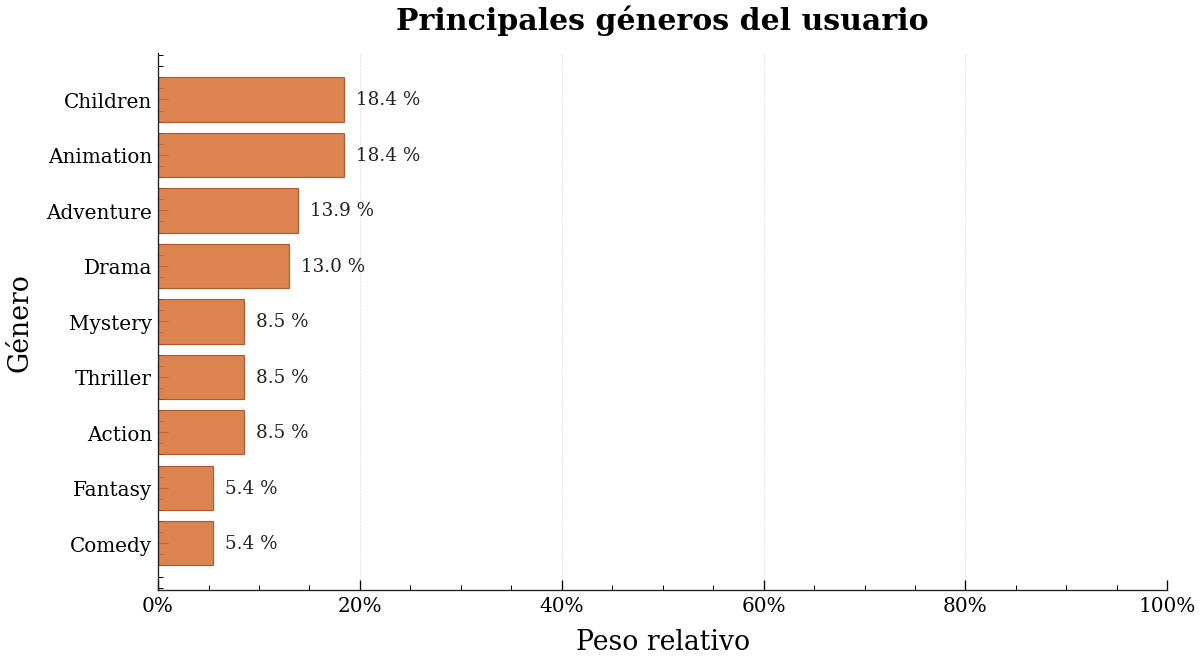


👥 Cinco usuarios más afines

Métrica: Similitud coseno (un valor mayor es mejor)


,Posición,Usuario,Similitud coseno,Afinidad relativa (%),Ratings observados,Ratings positivos,Rating promedio
0,1,33994,0.5649,56.5,702,346,3.68
1,2,136585,0.5259,52.6,822,372,3.49
2,3,88579,0.5136,51.4,305,214,4.04
3,4,116206,0.4981,49.8,490,204,3.61
4,5,103249,0.4976,49.8,164,45,2.80


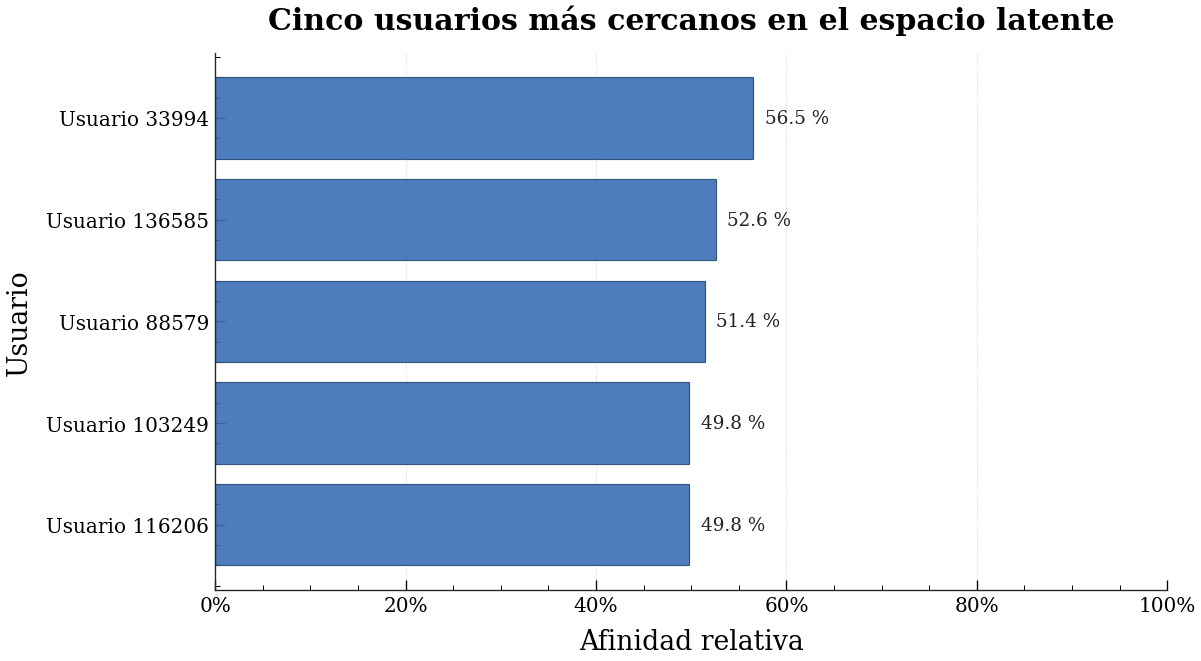


🤝 Evidencia social de los usuarios afines


,Posición,Usuario,Afinidad (%),Ratings positivos,Películas compartidas,Compartidas positivas,Apoyos al rollo,Positivas no vistas
0,1,33994,56.5,346,5,2,9,343
1,2,136585,52.6,372,5,2,9,370
2,3,88579,51.4,214,5,2,6,212
3,4,116206,49.8,204,5,2,8,201
4,5,103249,49.8,45,3,0,2,44



------------------------------------------------------------
👤 Vecino 1: usuario 33994
Afinidad relativa: 56.5%
Géneros principales: Drama (18.1%), Thriller (12.9%), Action (12.4%), Comedy (10.0%), Adventure (9.2%)

Coincidencias positivas con el usuario actual:
  • Ratatouille (2007) — usuario: 4.6, vecino: 4.5
  • Mission: Impossible (1996) — usuario: 4.4, vecino: 4.0

Películas del rollo respaldadas:
  • #1 Gladiator (2000) — rating 4.0
  • #2 Star Wars: Episode IV - A New Hope (1977) — rating 4.5
  • #3 Shrek (2001) — rating 4.5
  • #4 Finding Nemo (2003) — rating 4.5
  • #5 Ocean's Eleven (2001) — rating 5.0
  • #6 Pulp Fiction (1994) — rating 4.5
  • #7 WALL·E (2008) — rating 4.5
  • #8 Bourne Identity, The (2002) — rating 4.5
  • #10 Incredibles, The (2004) — rating 4.5

Principales películas positivas que el usuario no ha calificado:
  • All Is Lost (2013) — rating 5.0
  • Avengers, The (2012) — rating 5.0
  • Avengers: Infinity War - Part I (2018) — rating 5.0
  • Burn After 

,Posición,Película,Afinidad SVD (%),Apoyos,Vecinos,Ratings reales
0,1,Gladiator (2000),79.2,4,"[33994, 136585, 88579, 116206]","[4.0, 4.5, 4.5, 5.0]"
1,2,Star Wars: Episode IV - A New Hope (1977),77.5,3,"[33994, 136585, 88579]","[4.5, 4.0, 5.0]"
2,3,Shrek (2001),77.3,5,"[33994, 136585, 88579, 116206, 103249]","[4.5, 4.5, 4.0, 4.5, 4.0]"
3,4,Finding Nemo (2003),75.6,3,"[33994, 136585, 116206]","[4.5, 4.0, 4.0]"
4,5,Ocean's Eleven (2001),75.4,3,"[33994, 136585, 116206]","[5.0, 5.0, 4.5]"
5,6,Pulp Fiction (1994),75.1,3,"[33994, 136585, 88579]","[4.5, 5.0, 5.0]"
6,7,WALL·E (2008),73.4,4,"[33994, 136585, 116206, 103249]","[4.5, 4.5, 5.0, 4.0]"
7,8,"Bourne Identity, The (2002)",73.3,4,"[33994, 136585, 88579, 116206]","[4.5, 4.5, 4.0, 4.5]"
8,9,Jurassic Park (1993),72.9,2,"[88579, 116206]","[4.0, 4.0]"
9,10,"Incredibles, The (2004)",72.6,3,"[33994, 136585, 116206]","[4.5, 4.0, 4.5]"



🌟 Descubrimientos sociales


,ID,Película,Géneros,Vecinos que respaldan,Rating promedio,Afinidad social (%),Afinidad SVD (%),Score combinado (%),Usuarios que respaldan
0,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,5,4.80,100.0,100.0,100.0,"[33994, 136585, 88579, 116206, 103249]"
1,7153,"Lord of the Rings: The Return of the King, The...",Action|Adventure|Drama|Fantasy,5,4.60,87.8,90.8,88.7,"[33994, 136585, 88579, 116206, 103249]"
2,5952,"Lord of the Rings: The Two Towers, The (2002)",Adventure|Fantasy,5,4.60,86.2,89.7,87.3,"[33994, 136585, 88579, 116206, 103249]"
3,58559,"Dark Knight, The (2008)",Action|Crime|Drama|IMAX,4,5.00,88.2,84.2,87.0,"[33994, 136585, 88579, 116206]"
4,4993,"Lord of the Rings: The Fellowship of the Ring,...",Adventure|Fantasy,4,4.88,81.9,92.7,85.2,"[33994, 136585, 88579, 116206]"
5,79132,Inception (2010),Action|Crime|Drama|Mystery|Sci-Fi|Thriller|IMAX,5,4.60,87.6,79.3,85.1,"[33994, 136585, 88579, 116206, 103249]"
6,1291,Indiana Jones and the Last Crusade (1989),Action|Adventure,5,4.50,81.1,62.5,75.5,"[33994, 136585, 88579, 116206, 103249]"
7,2959,Fight Club (1999),Action|Crime|Drama|Thriller,4,4.62,69.6,85.2,74.3,"[33994, 136585, 88579, 116206]"
8,1196,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi,4,4.62,69.3,71.1,69.8,"[33994, 136585, 88579, 116206]"
9,356,Forrest Gump (1994),Comedy|Drama|Romance|War,4,4.50,62.2,85.4,69.1,"[33994, 88579, 116206, 103249]"



🕸️ Mapa de Afinidades


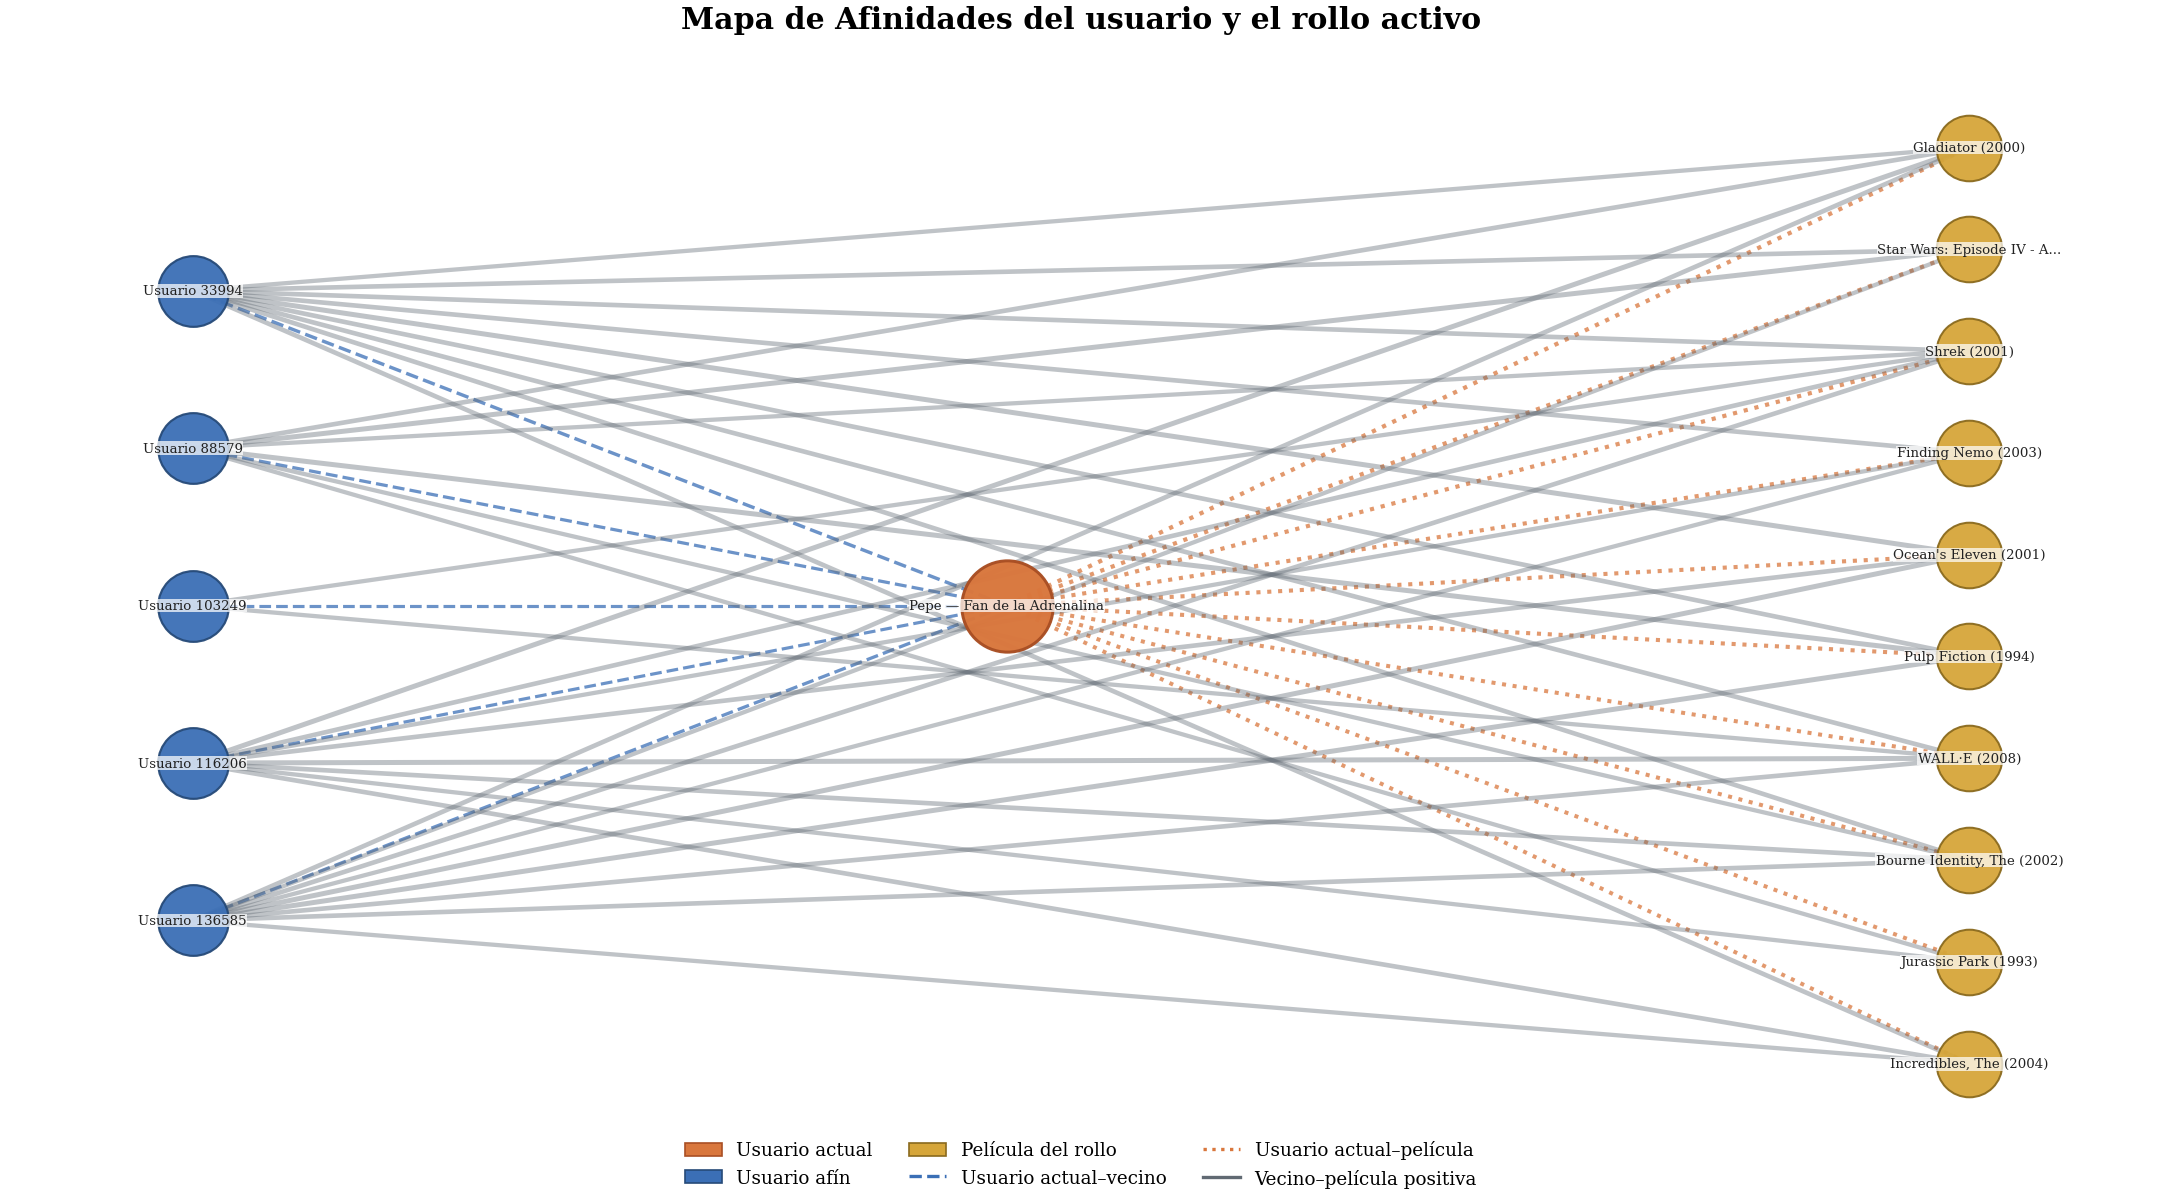

In [134]:
# ============================================================
# CORRER PEACH
# ============================================================

result = run_recommendation_app(
    movies_clean=movies_clean,
    movie_stats=movie_stats,
    tags_clean=tags_clean,
    Q=Q,
    movie_id_to_col=movie_id_to_col,
    col_to_movie_id=col_to_movie_id,
    movie_genres_lookup=movie_genres_lookup,
    user_affinity_index=user_affinity_index,
    block_size=ROLL_SIZE,
    top_n_per_genre=TOP_N_PER_GENRE,
    n_recommendations=N_RECOMMENDATIONS,
    lambda_reg=LAMBDA_REG,
    affinity_metric=AFFINITY_METRIC
)

# Estado general
new_user = result["new_user"]
user_identity = result["user_identity"]

# Recomendación individual
p_user = result["p_user"]
top_30 = result["top_30"]
active_roll = result["active_roll"]
roll_index = result["roll_index"]

# Explicación por géneros
taste_profile = result["taste_profile"]
taste_profile_source = result[
    "taste_profile_source"
]

# Usuarios afines con evidencia social
neighbors = result["neighbors"]
affinity_metric = result["affinity_metric"]

# Explicaciones y descubrimientos
movie_explanations = result[
    "movie_explanations"
]
social_discoveries = result[
    "social_discoveries"
]

# Grafo
affinity_graph = result[
    "affinity_graph"
]
map_available = result[
    "map_available"
]

In [135]:
# ============================================================
# ESTADO PRODUCIDO POR LA EXPERIENCIA
# ============================================================

print("Modo seleccionado:", new_user["mode"])
print(
    "Películas calificadas:",
    len(new_user.get("ratings", {}))
)
print("Tamaño del ranking:", len(top_30))
print(
    "Tamaño del rollo activo:",
    len(active_roll)
)
print(
    "Ronda activa:",
    roll_index + 1
    if roll_index >= 0
    else "No disponible"
)
print(
    "Fuente del perfil de gustos:",
    taste_profile_source
)
print(
    "Géneros en el perfil:",
    len(taste_profile)
)
print(
    "Métrica de afinidad:",
    affinity_metric
)
print(
    "Usuarios afines encontrados:",
    len(neighbors)
)
print(
    "Descubrimientos sociales:",
    len(social_discoveries)
)
print(
    "Nodos del mapa:",
    affinity_graph["node_count"]
    if affinity_graph
    else 0
)
print(
    "Conexiones del mapa:",
    affinity_graph["edge_count"]
    if affinity_graph
    else 0
)
print(
    "Mapa disponible:",
    map_available
)


if new_user["mode"] == "svd":
    # --------------------------------------------------------
    # Perfil latente, ranking y perfil de gustos
    # --------------------------------------------------------

    assert p_user is not None
    assert p_user.shape == (K,)
    assert len(top_30) <= N_RECOMMENDATIONS
    assert len(active_roll) == ROLL_SIZE

    assert isinstance(taste_profile, list)
    assert len(taste_profile) > 0

    profile_total = sum(
        item["weight"]
        for item in taste_profile
    )

    assert abs(profile_total - 100.0) <= 1.0

    # --------------------------------------------------------
    # Vecinos y evidencia social
    # --------------------------------------------------------

    assert isinstance(neighbors, list)
    assert len(neighbors) == N_NEIGHBORS

    neighbor_ids = [
        int(neighbor["userId"])
        for neighbor in neighbors
    ]

    assert len(set(neighbor_ids)) == N_NEIGHBORS

    metric_values = [
        float(neighbor["metric_value"])
        for neighbor in neighbors
    ]

    if affinity_metric == "cosine":
        assert all(
            metric_values[i]
            >= metric_values[i + 1] - 1e-12
            for i in range(len(metric_values) - 1)
        )
    else:
        assert all(
            metric_values[i]
            <= metric_values[i + 1] + 1e-12
            for i in range(len(metric_values) - 1)
        )

    for neighbor in neighbors:
        assert (
            int(user_ids[neighbor["row_index"]])
            == int(neighbor["userId"])
        )

        assert (
            neighbor["n_ratings"]
            >= MIN_NEIGHBOR_RATINGS
        )

        assert all(
            item["neighbor_rating"]
            >= POSITIVE_THRESHOLD
            for item in neighbor[
                "positive_ratings"
            ]
        )

    # --------------------------------------------------------
    # Explicación del rollo
    # --------------------------------------------------------

    assert isinstance(
        movie_explanations,
        pd.DataFrame
    )

    assert len(movie_explanations) == ROLL_SIZE

    active_roll_ids = {
        int(movie_id)
        for movie_id in active_roll[
            "movieId"
        ].tolist()
    }

    explanation_ids = {
        int(movie_id)
        for movie_id in movie_explanations[
            "movieId"
        ].tolist()
    }

    assert explanation_ids == active_roll_ids

    assert all(
        int(count) >= 0
        for count in movie_explanations[
            "support_count"
        ]
    )

    # --------------------------------------------------------
    # Descubrimientos sociales
    # --------------------------------------------------------

    assert isinstance(
        social_discoveries,
        pd.DataFrame
    )

    assert len(social_discoveries) <= N_SOCIAL_DISCOVERIES

    discovery_ids = [
        int(movie_id)
        for movie_id in social_discoveries[
            "movieId"
        ].tolist()
    ]

    rated_ids = {
        int(movie_id)
        for movie_id in new_user.get(
            "ratings",
            {}
        )
    }

    assert len(discovery_ids) == len(
        set(discovery_ids)
    )

    assert not (
        set(discovery_ids)
        & rated_ids
    )

    assert not (
        set(discovery_ids)
        & active_roll_ids
    )

    assert all(
        int(count) >= 1
        for count in social_discoveries[
            "support_count"
        ]
    )

    # --------------------------------------------------------
    # Grafo final
    # --------------------------------------------------------

    assert affinity_graph is not None

    graph = affinity_graph["graph"]

    expected_nodes = (
        1
        + N_NEIGHBORS
        + ROLL_SIZE
    )

    assert graph.number_of_nodes() == expected_nodes
    assert affinity_graph["node_count"] == expected_nodes

    node_type_counts = {
        "current_user": 0,
        "neighbor": 0,
        "movie": 0
    }

    for _, data in graph.nodes(data=True):
        node_type_counts[
            data["node_type"]
        ] += 1

    assert node_type_counts["current_user"] == 1
    assert node_type_counts["neighbor"] == N_NEIGHBORS
    assert node_type_counts["movie"] == ROLL_SIZE

    assert map_available

    # --------------------------------------------------------
    # Resumen final
    # --------------------------------------------------------

    print(
        "\nSuma del perfil de gustos:",
        round(profile_total, 1)
    )

    print(
        "IDs de los cinco vecinos:",
        neighbor_ids
    )

    print(
        "Valores de afinidad:",
        [
            round(value, 4)
            for value in metric_values
        ]
    )

    print(
        "Películas explicadas:",
        len(movie_explanations)
    )

    print(
        "Descubrimientos sociales generados:",
        len(social_discoveries)
    )

    print(
        "Estructura del mapa:",
        node_type_counts
    )

    print(
        "\n✅ Sistema Peach y Mapa de Afinidades "
        "preparados correctamente."
    )

Modo seleccionado: svd
Películas calificadas: 5
Tamaño del ranking: 30
Tamaño del rollo activo: 10
Ronda activa: 2
Fuente del perfil de gustos: positive_ratings
Géneros en el perfil: 9
Métrica de afinidad: cosine
Usuarios afines encontrados: 5
Descubrimientos sociales: 10
Nodos del mapa: 16
Conexiones del mapa: 49
Mapa disponible: True

Suma del perfil de gustos: 100.0
IDs de los cinco vecinos: [33994, 136585, 88579, 116206, 103249]
Valores de afinidad: [0.5649, 0.5259, 0.5136, 0.4981, 0.4976]
Películas explicadas: 10
Descubrimientos sociales generados: 10
Estructura del mapa: {'current_user': 1, 'neighbor': 5, 'movie': 10}

✅ Sistema Peach y Mapa de Afinidades preparados correctamente.


## Referencias

- Harper, F. M., & Konstan, J. A. (2015). *The MovieLens Datasets: History and Context*. ACM Transactions on Interactive Intelligent Systems, 5(4), 1–19. https://doi.org/10.1145/2827872
- GroupLens Research. (2024). *MovieLens 32M Dataset*. University of Minnesota. https://grouplens.org/datasets/movielens/32m/
- Golub, G. H., & Van Loan, C. F. (2013). *Matrix Computations* (4th ed.). Johns Hopkins University Press.
- Trefethen, L. N., & Bau, D. (1997). *Numerical Linear Algebra*. SIAM.
- Boyd, S., & Vandenberghe, L. (2018). *Introduction to Applied Linear Algebra: Vectors, Matrices, and Least Squares*. Cambridge University Press.